![title](notebook_images/logo.png)

# Biometrics System Concepts
## Assignment 3: Face Recognition
<b>Name</b>: Joe |
<b>Student-nr</b>: KD6-3.7 |
<b>Date</b>: July 1, 2049
---
Facial biometrics is among the most common biometric benchmarks. That is due to the easy deployment and implementation of such a system and the lack of requirement of physical interaction by the end-user. The top three application categories where facial recognition are mostly used are:
* Security - law enforcement: e.g. to find missing children/disoriented adults, or to identify and track criminals  
* Health care: e.g. for detecting genetic diseases, pain management or monitoring response to medication.
* Banking and retails: Since the beginning of the digital revolution, facial recognition has been picking up prominence over touch- and type-based interactions because of the convenience it offers without settling on the security of transactions. Facial Recognition softwares for banking usually have a liveness detection which keeps hackers from utilizing an image of the user for impersonation purposes.

Any facial recognition system requires the implementation of the following steps:
<pre>
1. Face detection, to detect faces from a given image.
2. Feature extraction, to extract feature vector descriptors from the raw face image.
3. Face matching process, for verification or identification purposes.
</pre>

In this assignment, you will implement, test and report about a face recognition system based on Principal Components Analysis (Eigenfaces), Linear Discriminant Analysis (Fisherfaces), Local Binary Pattern (LBP) and deep learning. The first three procedures are representative of old-school computer vision techniques that are still in use and retain their merits. All four generated feature vector descriptors can be compared for verification/identification.

This document is structured as follows:
* [Ethics](#Ethics)
* [Importing and installing packages](#Importing-and-installing-packages)
* [I. Loading data](#I.-Loading-data)
    * Read caltech dataset
    * Inspect some images   
    
* [II. Face detection](#II.-Face-detection)
    * Detect faces
    * Print statistics of data
    * Visualise some faces
    
* [III. Feature-extraction](#III.-Feature-extraction)
    * Eigenfaces for face recognition
    * Fisherfaces for face recognition
    * LBP for face recognition
    * Deep metric learning
        
* [IV. Distance-based and classification-based scoring](#IV.-Distance-based-and-classification-based-scoring)
* [V. Evaluation](#V.-Evaluation)
    * Validation as verification system
    * Validation as identification system
    
* [VI. Tasks](#VI.-Tasks)
    * Mandatory tasks
    * Tasks of choice


** Note 1: In case you find yourself needing extra computational power you can make use of [google colab](https://colab.research.google.com/). However, implementing overly complicated routines is discouraged. **

**Note 2: large parts of this notebook are based on the [PyImageSearch Gurus Course on Computer Vision](https://www.pyimagesearch.com/pyimagesearch-gurus/) by Adrian Rosebrock.**

## Ethics
The ethical and societal challenge posed by data protection is radically affected by the use of facial recognition technologies.

In Europe and the UK, the [General Data Protection Regulation](https://www.thalesgroup.com/en/markets/digital-identity-and-security/government/biometrics/biometric-data) (GDPR) provides a rigorous framework for these practices.

Any investigations into a citizen's private life or business travel habits are out of the question, and any such invasions of privacy carry severe penalties.

Applicable from May 2018, the GDPR supports the principle of a harmonized European framework, in particular protecting the right to be forgotten and the giving of consent through clear affirmative action.






## Importing and installing packages
Note: this exercise makes use of keras, which is now part of TensorFlow 2.0. It is easy to install using pip, have a look at the [installation guide](https://www.tensorflow.org/install) for more information. Note that you need Python Version 3.5 to 3.7 for this to run (not lower, not higher).

In [4]:
import numpy as np
import cv2
from pathlib import Path

from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.pyplot as plt
%matplotlib inline

# the following package contains some handy routines for image manipulation
# they have been developed by Adrian Rosenbrock
# simply install this package in your environment using "conda install imutils"
# see https://www.pyimagesearch.com/opencv-tutorials-resources-guides/ for further info
import imutils

# the following packages are imported when needed throughout this notebook,
# we are only listing them here so that you can install all necessary packages upfront.
# pandas
# sklearn
# enum
# scipy
# tensorflow.keras

## I. Loading data

[From OpenCV Docs](https://docs.opencv.org/3.4/da/d60/tutorial_face_main.html):

In order to test face recognition systems, we need databases of labeled face images. You can either create your own dataset (but that takes time) or, better, start with one of the available face databases, http://face-rec.org/databases/ gives you an up-to-date overview. Some interesting databases are:

* [AT&T Facedatabase](https://cam-orl.co.uk/facedatabase.html). Quoted from http://face-rec.org):
> The AT&T Facedatabase, sometimes also referred to as ORL (Olivetti Research Lab) Database of Faces or Olivetti faces, contains ten different images of each of 40 distinct subjects. For some subjects, the images were taken at different times, varying the lighting, facial expressions (open / closed eyes, smiling / not smiling) and facial details (glasses / no glasses). All the images were taken against a dark homogeneous background with the subjects in an upright, frontal position (with tolerance for some side movement).The AT&T Facedatabase is good for initial tests, but it's a fairly easy database. The Eigenfaces method already has a 97% recognition rate on it, so you won't see any great improvements with other algorithms.

This database can be accessed in a straightforward way through the [sklearn.datasets.fetch_olivetti_faces](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html#sklearn.datasets.fetch_olivetti_faces) module.
A preview of this database can be seen [here](https://git-disl.github.io/GTDLBench/datasets/att_face_dataset/)

* [The CALTECH Faces dataset](https://data.caltech.edu/records/6rjah-hdv18) is a popular benchmark dataset for face recognition algorithms. Overall, the dataset consists of 450 images of approximately 27 unique people. Each subject was captured under various lighting conditions, background scenes, and facial expressions. Furthermore, bounding box coordinates are provided to crop the faces prior to recognition. A routine (load_caltech_faces)is provided to read the data.

![A sample of the CALTECH Faces dataset.](notebook_images/lbps_fr_caltech_faches.jpg)

* [The Labeled Faces in the Wild (lfw)](http://vis-www.cs.umass.edu/lfw/). This dataset is a collection of more than 13000 JPEG pictures of famous people collected over the internet. Each face has been labeled with the name of the person pictured. 1680 of the people pictured have two or more distinct photos in the data set. These images are completely unconstrained (pose, illumination, expression, occlusion).  The only constraint on these faces is that they were detected by the Viola-Jones face detector. Each picture is centered on a single face. A loader [sklearn.datasets.fetch_lfw_people](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html#sklearn.datasets.fetch_lfw_people) is provided by scikit-learn.


### 1. Read caltech dataset
For this assignemnt we'll work with the CALTECH dataset because it contains raw images and is not very large. A copy of the dataset is available in the folder "CalTechFacesDirs".

The data are returned as a list object with the following components:
* data: (NxM) matrix of N flattened (linear dimension M) images
* images: (Nx(nxm)) matrix of N images of dimension nxm
* target: N-dimensional vector of labels

In [5]:
# size of each face after preprocessing
face_size=(47, 47)

In [6]:
import pandas as pd

def read_img(imagePath):
    # load the image and convert it to grayscale
    gray = cv2.imread(str(imagePath), cv2.IMREAD_GRAYSCALE)

    # ROI, and resize it to a canonical size
    imagePathStem = str(imagePath.stem)
    k = int(imagePathStem[imagePathStem.rfind("_") + 1:][:4]) - 1


    return gray, imagePath.parent.name

# grab in all the subdirs all the image paths associated with the faces
datasetPath = Path("CalTechFacesDirs")
imagePaths = datasetPath.glob("*/*.jpg")

# read image and label information
imgs = [read_img(imagePath) for imagePath in imagePaths]
data = pd.DataFrame(imgs, columns =['images', 'target']).to_dict('list')

# check if all images were found successfully
# Please note that 5 images were removed from the original set, because
# they wouldn't match the corresponding individual.
assert len(data['images']) == len(data['target']) == 445

In [7]:
# display data structure
display(data)

{'images': [array([[98, 94, 96, ..., 55, 51, 45],
         [94, 93, 95, ..., 55, 53, 43],
         [96, 95, 95, ..., 53, 53, 35],
         ...,
         [71, 72, 72, ...,  4,  1,  0],
         [74, 78, 72, ...,  3,  1,  0],
         [73, 65, 72, ...,  1,  1,  1]], dtype=uint8),
  array([[168, 167, 151, ..., 141, 134, 115],
         [163, 168, 157, ..., 136, 134, 116],
         [161, 178, 180, ..., 135, 133, 117],
         ...,
         [ 50,  48,  53, ...,  48,  50,  25],
         [127, 135, 137, ...,  42,  43,  21],
         [ 87, 113, 128, ...,  38,  42,  30]], dtype=uint8),
  array([[193, 193, 193, ..., 104, 105,  72],
         [192, 192, 192, ..., 103, 105,  82],
         [194, 195, 196, ..., 102, 108,  84],
         ...,
         [ 66,  72,  70, ..., 118, 117, 129],
         [ 73,  77,  76, ..., 119, 118, 124],
         [ 80,  85,  90, ..., 118, 118, 120]], dtype=uint8),
  array([[ 11,   7,  11, ..., 109, 107, 141],
         [  8,   6,  11, ..., 112, 110, 144],
         [  9,   9,

### 2. Inspect some images

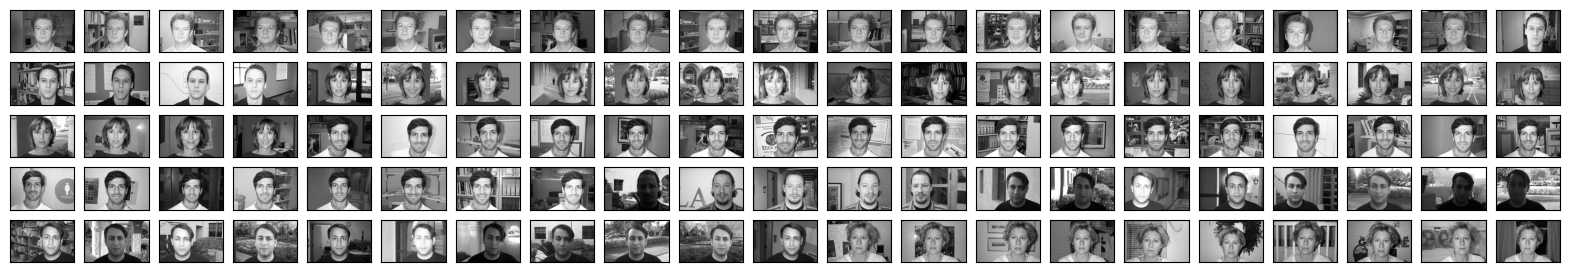

In [8]:
fig = plt.figure(figsize=(20, 20))
grid = ImageGrid(fig, 111,
                 nrows_ncols=(5, 21),
                 axes_pad=0.1,
                 )

for ax, im in zip(grid, data['images']):
    # Iterating over the grid returns the Axes.
    ax.imshow(im, cmap = 'gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

## II. Face detection


Even though the bounding box coordinates are stored in the <em>CalTechFacesDirs/ImageData.mat</em> file, we'll be computing them from scratch for demonstrative purposes.

### 1. Detect faces
There are many different face detection algorithms, you can follow the [Learn OpenCV tutorial on Face Detection](https://www.learnopencv.com/face-detection-opencv-dlib-and-deep-learning-c-python/) for some (very coarse) background info for two "conventional" (HAAR-cascade, HOG) CV methods and two Deep Neural Net (Dlib) based (SSD, MMOD) methods.

* Some background on Haar, HOG and MMOD face detectors can be found in this [Guide to Face Detection in Python](https://towardsdatascience.com/a-guide-to-face-detection-in-python-3eab0f6b9fc1).

* For MMOD specifically, see: [Max-Margin Object Detection by Davis E. King](http://arxiv.org/abs/1502.00046) and the comments at the beginning of the [dnn_mmod_ex.cpp code](https://github.com/davisking/dlib/blob/master/examples/dnn_mmod_ex.cpp).

* For further info on the Single-Shot-Multibox Detector, see [the arXiv publication](https://arxiv.org/abs/1512.02325).

In this assignment we'll be using HAAR, you can find more information about this technique on the [OpenCV website](https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html).

In [9]:
faceCascade = cv2.CascadeClassifier('./models/haarcascade_frontalface_default.xml')

In [10]:
from sklearn.utils import Bunch
from sklearn.preprocessing import LabelEncoder

feat_data, images, labels = [], [], []


for img, label in zip(data['images'], data['target']):
    faces = faceCascade.detectMultiScale(
        img,
        scaleFactor = 1.2,
        minNeighbors = 9,
        minSize = (30, 30),
        flags = cv2.CASCADE_SCALE_IMAGE
    )

    # iterate faces found in image
    for (x, y, w, h) in faces:
        new_img = img.copy()

        # extract ROI
        raw_face = new_img[y:y+h, x:x+w]

        # resize the face to the preferred size
        face = cv2.resize(raw_face, face_size)
        face_flatten = face.flatten()

        images.append(np.expand_dims(face, axis=-1)), feat_data.append(face_flatten), labels.append(label)

# encode classes as integer value
label_encoder = LabelEncoder()
targets = label_encoder.fit_transform(labels)

faces = Bunch(data       = np.array(feat_data),
              images     = np.array(images),
              labels     = np.array(labels),
              target     = np.array(targets))

### 2. Print statistics of data

In [11]:
# extract number of samples and image dimensions (for later display)
n_samples, h, w, n_channels = faces.images.shape
imshape = (h, w, n_channels)

# count number of individuals
n_classes = faces.target.max() +1

n_features = faces.data.shape[1]

print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_classes: %d" % n_classes)
print("n_features: %d" % n_features)

Total dataset size:
n_samples: 440
n_classes: 26
n_features: 2209


### 3. Visualise some faces

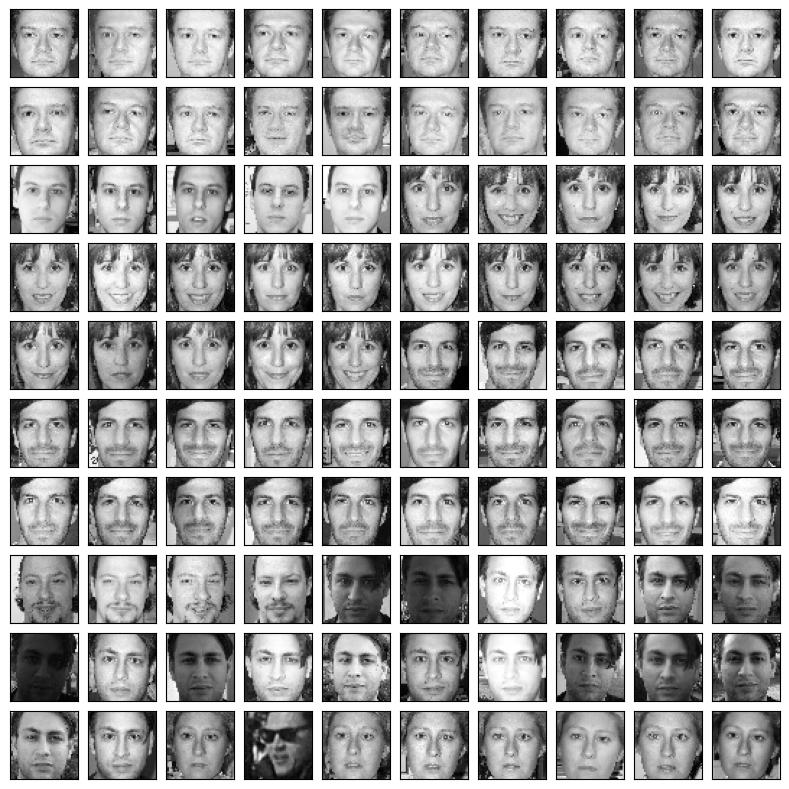

In [12]:
fig = plt.figure(figsize=(10, 10))
grid = ImageGrid(fig, 111,
                 nrows_ncols=(10, 10),
                 axes_pad=0.1,
                 )

for ax, im in zip(grid, faces['images']):
    # Iterating over the grid returns the Axes.
    ax.imshow(np.mean(im, -1), cmap = 'gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

## III. Feature extraction

Images tend to be large and can differ a lot in lighting, positioning, ... To combat this we'll extract features from each image using 4 different techniques. They all belong to the global/holistic feature representation approaches that map the image to a lower-dimensional subspace through linear and non-linear mapping.

In [10]:
from enum import Enum
from sklearn.model_selection import train_test_split

# split data for training and testing
holdout_split = lambda X,y: train_test_split(X, y, test_size=.25, shuffle = True,
                                             stratify = y, random_state = 22)

class FeatureDescriptor(Enum):
    LBP = 1
    PCA = 2
    LDA = 3
    DL = 4

######################################
# select the technique you want to use
DESC = FeatureDescriptor.DL
######################################

# number of PCA/LDA components to retain
num_components = 35

### 1. Eigenfaces for face recognition

From [PyImageSearch Gurus Course on Computer Vision](https://www.pyimagesearch.com/pyimagesearch-gurus/) by Adrian Rosebrock:
>In 1971 Goldstein et al. [Identification of human faces](https://ieeexplore.ieee.org/document/1450184) demonstrated that facial characteristics can be manually extracted, quantified and used for face recognition. The question then remained: could this be done in an automatic fashion?

>It wasn’t until the 1987 paper by Kirby and Sirovich ([A Low-Dimensional Procedure for the Characterization of Human Faces](https://www.researchgate.net/publication/19588504_Low-Dimensional_Procedure_for_the_Characterization_of_Human_Faces)) that we were able to answer this question. This paper is considered to be a seminal work in the history of computer vision — and while other approaches have since been proposed that can outperform Eigenfaces, it’s still important that we take the time to understand and appreciate this algorithm. [Turk and Pentland](https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=1&cad=rja&uact=8&ved=2ahUKEwjmvqy6jqfhAhWFZFAKHb74DNgQFjAAegQIABAC&url=http%3A%2F%2Fwww.face-rec.org%2Falgorithms%2Fpca%2Fjcn.pdf&usg=AOvVaw2IlxVps8dldmeA01yQDa_I) built on this idea in the context of face recognition.

>The Eigenfaces algorithm uses Principal Component Analysis to construct a low-dimensional representation of face images.

>![An example of applying an eigenvalue decomposition to a dataset of faces and extracting the 16 "eigenfaces" with the largest corresponding eigenvalue magnitude.](notebook_images/what_is_fr_eigenfaces.jpg)


>This involves collecting a dataset of faces with multiple face images per person we want to identify — like having multiple training examples of an image class we would want to label in image classification. Given this dataset of face images, presumed to be the same width, height, and ideally — with their eyes and facial structures aligned at the same (x, y)-coordinates, we apply an eigenvalue decomposition of the dataset, keeping the eigenvectors with the largest corresponding eigenvalues.

>Given these eigenvectors, a face can then be represented as a linear combination of what Kirby and Sirovich call eigenfaces.

>Face identification can be performed by computing the Euclidean distance between the eigenface representations and treating the face identification as a k-Nearest Neighbor classification problem — however, we tend to commonly apply more advanced machine learning algorithms to the eigenface representations.

>Last, it’s important to note that the Eigenfaces algorithm is **not-specific to faces** — we can actually apply it to any arbitrary dataset containing objects of the same type that need to be compared, whether that may be bicycles, cans of soup, or ancient Aztec coins. The Eigenfaces algorithm can be modified to accommodate each of these identification tasks.

In [ ]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import euclidean

if DESC == FeatureDescriptor.PCA:
    # Compute a PCA (eigenfaces) on the face dataset
    num_components = min(num_components, min(n_samples, n_features))
    print("num_components {n}".format(n=num_components))
    desc = PCA(n_components=num_components, svd_solver='randomized', whiten=True).fit(faces.data)
    X_pca = desc.transform(faces.data)
    embedded = X_pca

    dist_metric = euclidean

### 2. Fisherfaces for face recognition

From [Scholarpaedia](http://www.scholarpedia.org/article/Fisherfaces):
> When the goal is classification rather than representation, PCA may not yield the most desirable results. In such cases, one wishes to find a subspace that maps the sample vectors of the same class in a single spot of the feature representation and those of different classes as far apart from each other as possible. The techniques derived to achieve this goal are known as discriminant analysis (DA).
The most known DA is Linear Discriminant Analysis (LDA), which can be derived from an idea suggested by R.A. Fisher in 1936. When LDA is used to find the subspace representation of a set of face images, the resulting basis vectors defining that space are known as [Fisherfaces](http://www.scholarpedia.org/article/Fisherfaces).

![Example of FisherFaces](notebook_images/FisherFaces.jpg)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.spatial.distance import euclidean

if DESC == FeatureDescriptor.LDA:
    num_components = min(num_components, min(n_classes - 1, n_features))
    desc = LinearDiscriminantAnalysis(n_components=num_components).fit(faces.data, faces.target)
    X_lda = desc.fit_transform(faces.data, faces.target)
    embedded = X_lda

    dist_metric = euclidean

### 3. LBP for face recognition

Local Binary Patterns, or LBPs for short, are a texture descriptor made popular by the work of Ojala et al. in their 2002 paper, [Multiresolution Grayscale and Rotation Invariant Texture Classification with Local Binary Patterns](https://ieeexplore.ieee.org/document/1017623) (although the concept of LBPs were introduced as early as 1993).

Unlike [Haralick texture features](http://haralick.org/journals/TexturalFeatures.pdf) that compute a global representation of texture based on the [Gray Level Co-occurrence Matrix](https://en.wikipedia.org/wiki/Co-occurrence_matrix), LBPs instead compute a local representation of texture. This local representation is constructed by comparing each pixel with its surrounding neighborhood of pixels. See [PyImageSearch](https://www.pyimagesearch.com/2015/12/07/local-binary-patterns-with-python-opencv/) and [Scikit-Image](http://scikit-image.org/docs/dev/auto_examples/features_detection/plot_local_binary_pattern.html) for further details on LBP.
![LBP](notebook_images/LBP.png)

In [ ]:
from localmodules.local_binary_patterns import LBP
from scipy.stats import chisquare

if DESC == FeatureDescriptor.LBP:
    desc = LBP(numPoints=8, radius=1, grid_x=7, grid_y=7)
    embedded = desc.describe_list(faces.images[...,0])

    dist_metric = chisquare

# Hint: If you get NaN values as a result of Chi-Square, feel free to use the following function:

def CHI2(histA, histB, eps=1e-10):
    # compute the chi-squared distance
    d = 0.5 * np.sum(((histA - histB) ** 2) / (histA + histB + eps))

    # return the chi-squared distance
    return d

### 4. Deep metric learning
Similar to previous techniques, we can use deep learning to generate an enriched representation of faces that you can use in simple or more complicated classification algorithms.
Instead of building networks that are trained end-to-end to perform face recognition, we will use deep metric learning. Metric learning based methods learn a projection of the input data on a low-dimensional vector, such that classification in that lower-dimensional space is much easier and can be performed using simple distance metrics.

In the context of face recognition we can observe the following major Deep Learning based approaches since 2014.

1. The first approach was developed and presented in 2014 by researchers at Facebook and is called [DeepFace](https://www.cs.toronto.edu/~ranzato/publications/taigman_cvpr14.pdf) . The major contributions where a CDNN to classify faces. In addition a 3D/2D alignment procedure is applied prior to classification.
The CDNN is trained as a classifier on the SFC (Social Face Classification) dataset, which is a very large (4.4 million image of 4000 individuals) dataset. This setting is called supervised.  The challenge is whether this can also be generalizd to other datasets and subjects as well. By training it on the large collection of uncontrolled images, an embedded representation (the vector description prior to the classification layer) can be generated that is, allegedly, generalizable to other face recognition data. One can then use this representation as we have previously done for classical representations.
By way of demonstration they tested it on the LFW dataset to achieve >0.95% verification accuracy. <br>

2. The second approach was developed by researchers at Google.  An in-depth presentation of their FaceNet/OpenFace deep CNN's for metric embedding of faces is given by [Martin Krasser et al](http://krasserm.github.io/2018/02/07/deep-face-recognition/). Note that this method was trained on 200 million images of eight million identities. The main methodological point is that these networks are trained using a special loss-function: the triplet loss function.
>This function is minimized when the distance between an anchor image $x_{ai}$ and a positive image $x_{pi}$ (same identity) in embedding space is smaller than the distance between that anchor image and a negative image $x_{ni}$ (different identity) by at least a margin $\alpha$. Model training aims to learn an embedding f(x) of image x such that the squared L2 distance between all faces of the same identity is small and the distance between a pair of faces from different identities is large.







There is a very elegant Python implementation available of the FaceNet/OpenFace approach. It is nicely described in [this PyImageSearch tutorial](https://www.pyimagesearch.com/2018/06/18/face-recognition-with-opencv-python-and-deep-learning/). It explicitly includes the Dlib package with the [face_recognition modules](https://face-recognition.readthedocs.io/en/latest/index.html) for face detection and recognition. Especially the latter package provides a very convenient interface.

From the [Dlib face_recognition.py](https://github.com/davisking/dlib/blob/master/python_examples/face_recognition.py) code, we get an application view of the embedding:

> This example shows how to use dlib's face recognition tool.  This tool maps an image of a human face to a 128 dimensional vector space where images of the same person are near to each other and images from different people are far apart.  Therefore, you can perform face recognition by mapping faces to the 128D space and then checking if their Euclidean distance is small enough.

> When using a distance threshold of 0.6, the dlib model obtains an accuracy of 99.38% on the standard LFW face recognition benchmark, which is comparable to other state-of-the-art methods for face recognition as of February 2017. This accuracy means that, when presented with a pair of face images, the tool will correctly identify if the pair belongs to the same person or is from different people 99.38% of the time.

In the [DeepFace](https://www.cs.toronto.edu/~ranzato/publications/taigman_cvpr14.pdf) paper they also tested a [siamese network](https://en.wikipedia.org/wiki/Siamese_network) DNN architecture for generating embedded vector representations.  This consists of two copies of the same CNN (sharing their weights) that are applied to pairs of images. During training the distance between the embedded representations of the same individual is minimized, and the distances between embedded representations of different individuals is maximized. In the mean time, this work was extended, steadily increasing the performance. Siamese networks are an example of *One-shot Learning* where you tyically have very few samples per object or dynamically changing number of objects/subjects. While [this link](https://towardsdatascience.com/one-shot-learning-with-siamese-networks-using-keras-17f34e75bb3d) tests it on a non-face recognition task, it can be applied to face recognition as well.

The localmodules.siamese file contains the description of a shallow CNN model that is trained with [contrastive loss](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf).
This subnetwork is copied twice and the output of both siamese copies are then passed onto a vector euclidean distance (ED) calculation layer. The network gets as input pairs of imposter or genuine images with the associated label (genuine = 0, imposter = 1). You can make use of the output of the network or the output before the ED layer (embedded) in your validation.

Note: this part on Siamese networks is adapted from [Packt tutorial](https://hub.packtpub.com/face-recognition-using-siamese-networks-tutorial/), which seems to be a re-implementation from  [this Packt book on Neural Network Projects with Python](https://subscription.packtpub.com/book/big_data_and_business_intelligence/9781789138900)). See also [this Hackernoon tutorial](https://hackernoon.com/one-shot-learning-with-siamese-networks-in-pytorch-8ddaab10340e).

Note: you can change the CNN at your will, but beware that it might take additional training time.

In [12]:
# If you encounter problem importing the siamese model, consider using Google Colab.
import localmodules.siamese as siamese

#some older versions may need this
# import tensorflow as tf
# tf.enable_eager_execution()


encoder, model = siamese.create_siamese_model(imshape, num_components)
model.summary()

NameError: name 'num_components' is not defined

In [ ]:
# To visualize your model structure:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes = True, show_layer_names = True)

Depending on the complexity of the Siamese network this might take a while. You can also change the number of epochs to improve the training (with the risk of overfitting). You will notice that a small number (<10) of epochs already gets you a decent performance.

In [ ]:
import localmodules.siamese as siamese
from tensorflow.keras.optimizers import RMSprop, Adam

from scipy.spatial.distance import euclidean
from sklearn.metrics import accuracy_score

if DESC == FeatureDescriptor.DL:
    x_train, x_test, y_train, y_test = holdout_split(*siamese.get_siamese_paired_data(faces.images, faces.target))
    rms = Adam()
    model.compile(
        loss=siamese.contrastive_loss,
        optimizer=rms,
        metrics = [siamese.accuracy],
        run_eagerly=True)

    epochs = 10
    model.fit([x_train[:, 0], x_train[:, 1]], y_train,
              validation_split=0.2,
              batch_size=32, verbose=2, epochs=epochs)

    test_scores = model.predict([x_test[:, 0], x_test[:, 1]])
    test_acc = accuracy_score(y_test, test_scores > 0.5)
    print("Accuracy on the test set: {}".format(test_acc))
    embedded = encoder(faces.images.astype(np.float32)).numpy()

    dist_metric = euclidean

## IV. Mandatory tasks

<b>The student should do all of the tasks indicated in this section</b>.
 All tasks should be accompanied by a text providing information on the technique, steps, and the reasoning behind choosing the techniques.


## 1. Distance-based and classification-based scoring

Biometrics is based on generating pairwise matching scores. In it's simplest form, the score is computed based on the distance metrics (distance-based scoring). E.g. a simple pairwise comparision (L2-distance, e.g.) can be used.

* In verification mode one compares this matching score to a decision threshold in a 1-to-1 setting.
* In identifcation mode one uses this matching score to rank the templates in the database and, possibly, thresholding it as well in a 1-to-N setting


On the other hand, some classification algorithms provide us with the classification scores (or probabilities), which are related to the likelihood that an image belongs to each subject in the dataset. These classification scores can be seen as an advanced classification-based matching score.

* In verification mode one compares the soft scores (or probabilities) of the classification with a threshold to verify whether the person is who he claims to be.
* In identifcation mode one sorts the soft scores to propose the most similar people in the dataset.

To implement a classification-based system (optional task 3), the following steps are expected:
1. For each person in the dataset leave one image out (E.g. the first image in the dataset) for the testset. This means the size of the test set equals the number of individuals in the data (=n).
2. Run the classifier of your choice and generate the classification probabilities for each test image.
3. Build your n by n similarity matrix, in which each row corresponds to a test image and each column corresponds to an individual in the dataset.
4. Calculate the evaluation metrics (E.g. ROC) based on the obtained similarity matrix to test your system in a verification or identification scenario.

In [13]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.spatial.distance import euclidean
from localmodules.local_binary_patterns import LBP
import localmodules.siamese as siamese
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

holdout_split = lambda X, y: train_test_split(X, y, test_size=.25, shuffle=True,
                                               stratify=y, random_state=22)

def CHI2(histA, histB, eps=1e-10):
    return 0.5 * np.sum(((histA - histB) ** 2) / (histA + histB + eps))

def compute_distance_matrix(embedded, dist_metric):
    n = len(embedded)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = dist_metric(embedded[i], embedded[j])
    return D

# ── PCA ───────────────────────────────────────────────────────────────────────
n_comp_pca = min(35, min(n_samples, n_features))
pca_desc   = PCA(n_components=n_comp_pca, svd_solver='randomized', whiten=True).fit(faces.data)
emb_pca    = pca_desc.transform(faces.data)
dist_pca   = compute_distance_matrix(emb_pca, euclidean)
print("PCA done")

# ── LDA ───────────────────────────────────────────────────────────────────────
n_comp_lda = min(35, n_classes - 1)
lda_desc   = LinearDiscriminantAnalysis(n_components=n_comp_lda).fit(faces.data, faces.target)
emb_lda    = lda_desc.transform(faces.data)
dist_lda   = compute_distance_matrix(emb_lda, euclidean)
print("LDA done")

# ── LBP ───────────────────────────────────────────────────────────────────────
lbp_desc   = LBP(numPoints=8, radius=1, grid_x=7, grid_y=7)
emb_lbp    = lbp_desc.describe_list(faces.images[..., 0])
dist_lbp   = compute_distance_matrix(emb_lbp, CHI2)
print("LBP done")

# ── DL ────────────────────────────────────────────────────────────────────────
encoder_dl, model_dl = siamese.create_siamese_model(imshape, 35)
x_train, x_test, y_train, y_test = holdout_split(
    *siamese.get_siamese_paired_data(faces.images, faces.target))
model_dl.compile(loss=siamese.contrastive_loss, optimizer=Adam(),
                 metrics=[siamese.accuracy], run_eagerly=True)
model_dl.fit([x_train[:, 0], x_train[:, 1]], y_train,
             validation_split=0.2, batch_size=32, verbose=2, epochs=10)
emb_dl   = encoder_dl(faces.images.astype(np.float32)).numpy()
dist_dl  = compute_distance_matrix(emb_dl, euclidean)
print("DL done")

dist_matrices = {'PCA': dist_pca, 'LDA': dist_lda, 'LBP': dist_lbp, 'DL': dist_dl}
systems = [('System 1 — PCA', dist_pca), ('System 2 — LDA', dist_lda),
           ('System 3 — LBP', dist_lbp), ('System 4 — DL',  dist_dl)]
print("All done!")

PCA done
LDA done
LBP done
Epoch 1/10
38/38 - 7s - loss: 0.1054 - accuracy: 0.7097 - val_loss: 0.0598 - val_accuracy: 0.8302 - 7s/epoch - 181ms/step
Epoch 2/10
38/38 - 6s - loss: 0.0426 - accuracy: 0.9112 - val_loss: 0.0393 - val_accuracy: 0.9052 - 6s/epoch - 162ms/step
Epoch 3/10
38/38 - 6s - loss: 0.0306 - accuracy: 0.9449 - val_loss: 0.0273 - val_accuracy: 0.9698 - 6s/epoch - 168ms/step
Epoch 4/10
38/38 - 7s - loss: 0.0196 - accuracy: 0.9770 - val_loss: 0.0241 - val_accuracy: 0.9698 - 7s/epoch - 178ms/step
Epoch 5/10
38/38 - 7s - loss: 0.0150 - accuracy: 0.9844 - val_loss: 0.0198 - val_accuracy: 0.9844 - 7s/epoch - 174ms/step
Epoch 6/10
38/38 - 7s - loss: 0.0127 - accuracy: 0.9885 - val_loss: 0.0198 - val_accuracy: 0.9750 - 7s/epoch - 179ms/step
Epoch 7/10
38/38 - 12s - loss: 0.0111 - accuracy: 0.9901 - val_loss: 0.0177 - val_accuracy: 0.9812 - 12s/epoch - 305ms/step
Epoch 8/10
38/38 - 9s - loss: 0.0094 - accuracy: 0.9959 - val_loss: 0.0159 - val_accuracy: 0.9812 - 9s/epoch - 241ms/

2026-05-07 09:34:14.550371: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.
2026-05-07 09:34:14.693558: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.
2026-05-07 09:34:15.071283: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.


DL done
All done!


<div class="alert alert-block alert-success">
<b>Q1: </b> Compute distance-based pair-wise matching scores.
</div>

Given the function <em>dist_metric</em> and the vector representations in variable <em>embedded</em>, compute the pairwise distances. Do this for PCA, LDA, LBP and a DL facial representations, given the code above.

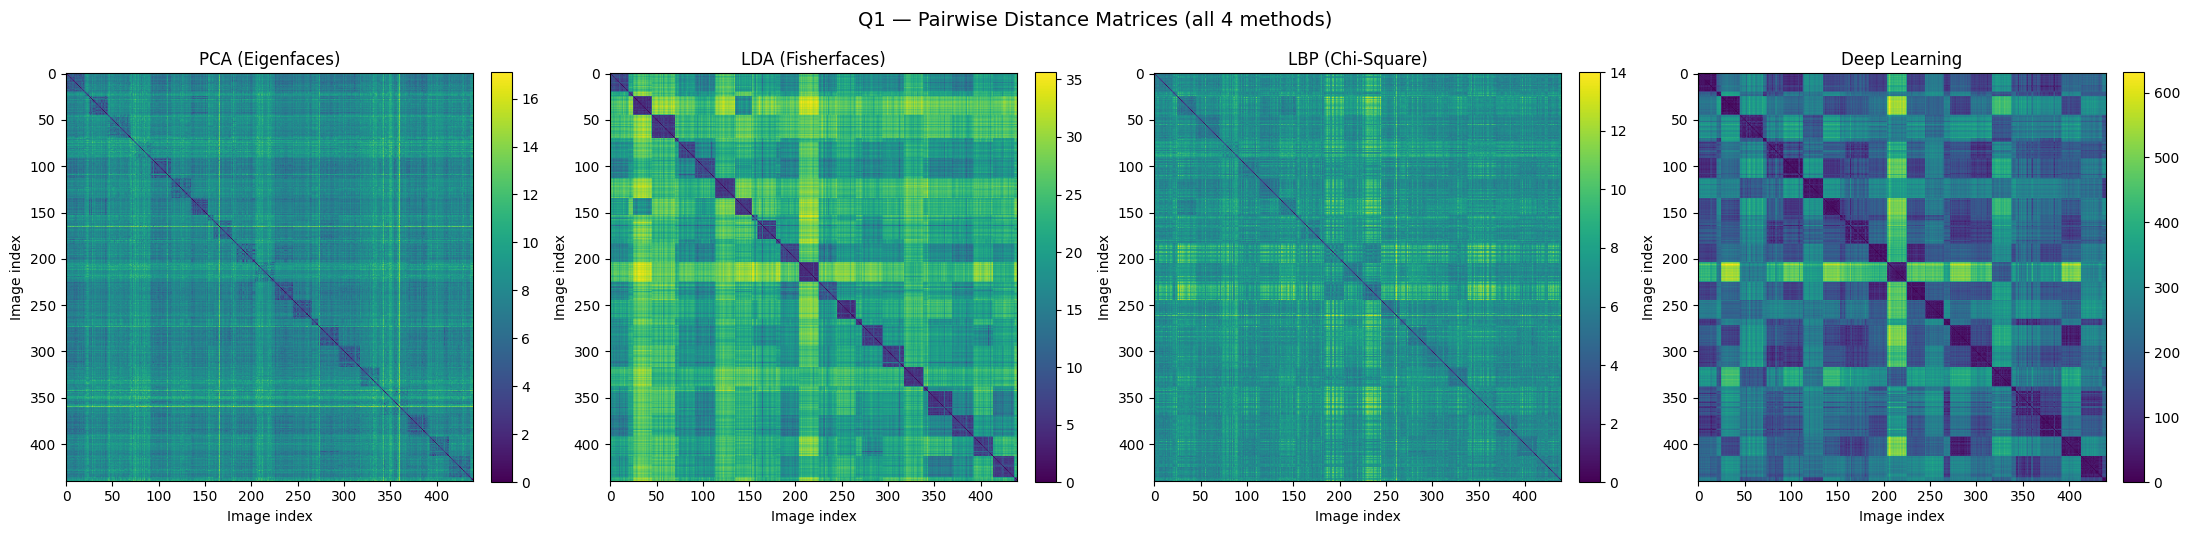

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

titles = {
    'PCA': 'PCA (Eigenfaces)',
    'LDA': 'LDA (Fisherfaces)',
    'LBP': 'LBP (Chi-Square)',
    'DL' : 'Deep Learning'
}

for ax, (name, matrix) in zip(axes, dist_matrices.items()):
    im = ax.imshow(matrix, cmap='viridis')
    ax.set_title(titles[name], fontsize=12)
    ax.set_xlabel("Image index")
    ax.set_ylabel("Image index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Q1 — Pairwise Distance Matrices (all 4 methods)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Evaluation

In this section you can re-use the code you developed for validation in the previous assignments, and in particular assignment 1.

### 2.1. Validation as verification system

<div class="alert alert-block alert-success">
<b>Q2: </b> Plot genuine and impostor scores
</div>
When comparing the different feature extractions/facial representations, discuss the difference in the overlap between genuine and imposter scores.

In [15]:
import numpy as np

def extract_scores(dist_matrix, labels):
    """
    From a distance matrix and label array, extract:
    - scores     : all pairwise distances (upper triangle, no diagonal)
    - genuine_id : 1 if same person, 0 if different
    """
    N = len(labels)
    scores     = []
    genuine_id = []
    
    for i in range(N):
        for j in range(i+1, N):  # upper triangle only, skip diagonal
            scores.append(dist_matrix[i, j])
            genuine_id.append(1 if labels[i] == labels[j] else 0)
    
    return np.array(genuine_id), np.array(scores)

# Extract for all 4 methods
labels = np.array(faces.target)

system1_genuine_id, system1_scores = extract_scores(dist_matrices['PCA'], labels)
system2_genuine_id, system2_scores = extract_scores(dist_matrices['LDA'], labels)
system3_genuine_id, system3_scores = extract_scores(dist_matrices['LBP'], labels)
system4_genuine_id, system4_scores = extract_scores(dist_matrices['DL'],  labels)

# Sanity check
for name, gid, sc in zip(['PCA','LDA','LBP','DL'],
                          [system1_genuine_id, system2_genuine_id, system3_genuine_id, system4_genuine_id],
                          [system1_scores,     system2_scores,     system3_scores,     system4_scores]):
    print(f"{name} | total pairs: {len(sc)} | genuine: {gid.sum()} | impostor: {(gid==0).sum()}")

PCA | total pairs: 96580 | genuine: 4210 | impostor: 92370
LDA | total pairs: 96580 | genuine: 4210 | impostor: 92370
LBP | total pairs: 96580 | genuine: 4210 | impostor: 92370
DL | total pairs: 96580 | genuine: 4210 | impostor: 92370


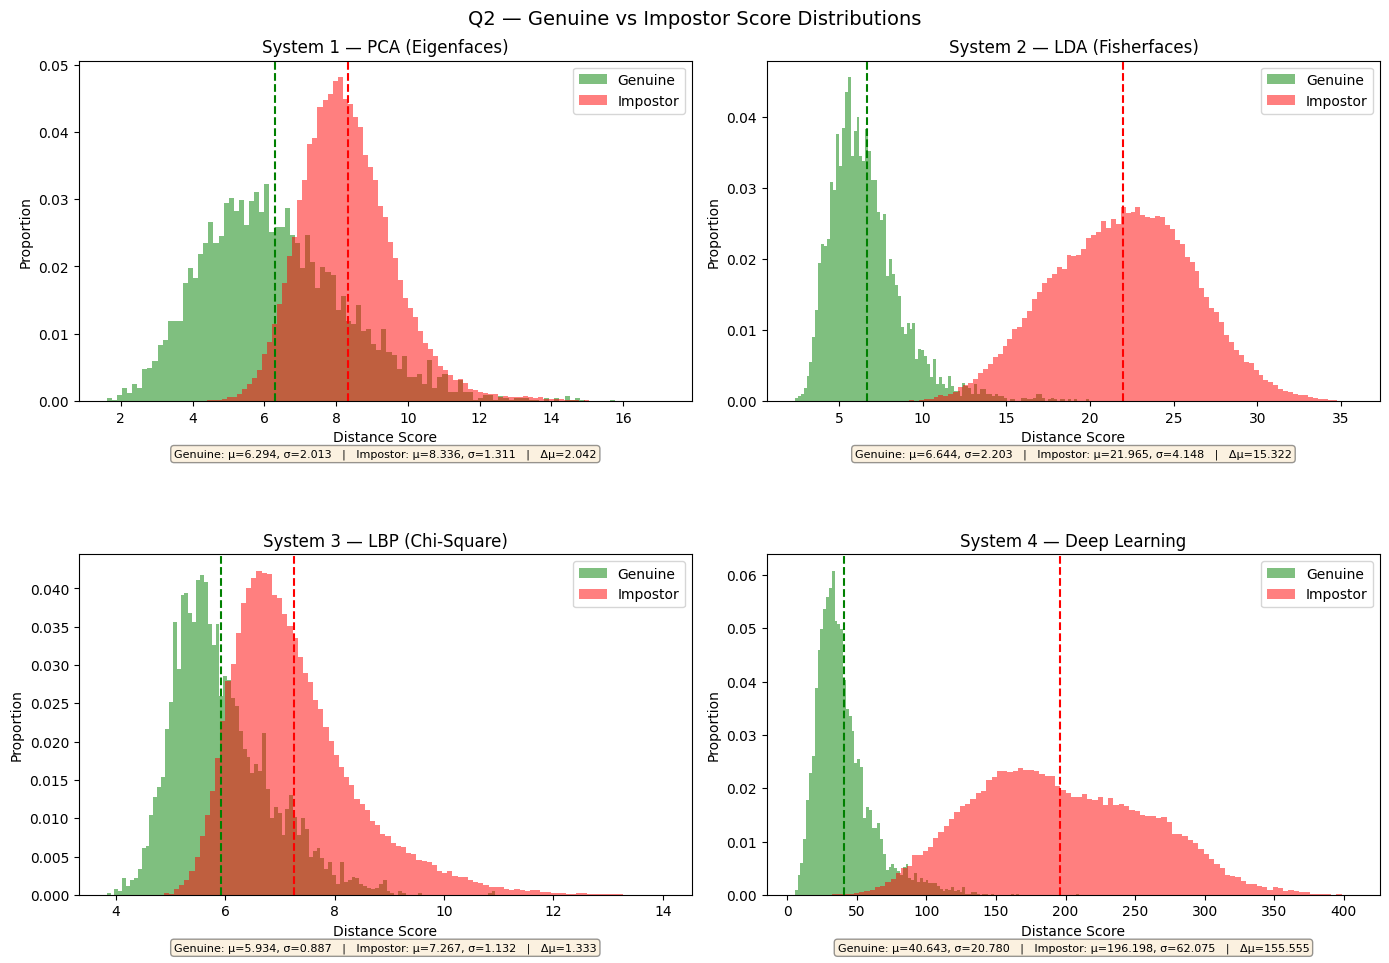

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

systems = [
    (system1_genuine_id, system1_scores, "System 1 — PCA (Eigenfaces)"),
    (system2_genuine_id, system2_scores, "System 2 — LDA (Fisherfaces)"),
    (system3_genuine_id, system3_scores, "System 3 — LBP (Chi-Square)"),
    (system4_genuine_id, system4_scores, "System 4 — Deep Learning"),
]

for idx, (genuine_id, scores, name) in enumerate(systems):
    ax = axes[idx]
    
    genuine_scores  = scores[genuine_id == 1]
    impostor_scores = scores[genuine_id == 0]
    
    ax.hist(genuine_scores,  bins=100, alpha=0.5, label="Genuine",  color="green",
            weights=np.ones_like(genuine_scores)  / len(genuine_scores))
    ax.hist(impostor_scores, bins=100, alpha=0.5, label="Impostor", color="red",
            weights=np.ones_like(impostor_scores) / len(impostor_scores))
    
    ax.axvline(genuine_scores.mean(),  color="green", linestyle="--", linewidth=1.5)
    ax.axvline(impostor_scores.mean(), color="red",   linestyle="--", linewidth=1.5)
    
    ax.set_title(name)
    ax.set_xlabel("Distance Score")
    ax.set_ylabel("Proportion")
    ax.legend()
    
    stats_text = (
        f"Genuine: μ={genuine_scores.mean():.3f}, σ={genuine_scores.std():.3f}   |   "
        f"Impostor: μ={impostor_scores.mean():.3f}, σ={impostor_scores.std():.3f}   |   "
        f"Δμ={impostor_scores.mean() - genuine_scores.mean():.3f}"
    )
    ax.text(0.5, -0.14, stats_text, transform=ax.transAxes,
            fontsize=8, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle("Q2 — Genuine vs Impostor Score Distributions", fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.subplots_adjust(hspace=0.45)
plt.show()

<div class="alert alert-block alert-success">
<b>Q3: </b> Compute F1 and accuracy scores for variable (and optimal) thresholds
</div>

* Calculate and plot F1 and accuracy scores for a range (min, max) of thresholds.
* Determine some optimal threshold (look up in classification literature). Justify your answer.

In [16]:
systems = [
    (system1_genuine_id, system1_scores, "System 1 — PCA"),
    (system2_genuine_id, system2_scores, "System 2 — LDA"),
    (system3_genuine_id, system3_scores, "System 3 — LBP"),
    (system4_genuine_id, system4_scores, "System 4 — DL"),
]

# Compute ROC data for all 4 systems (needed for F1/accuracy computation)
from sklearn.metrics import roc_curve

roc_data = {}
for genuine_id, scores, name in systems:
    fpr, tpr, thresholds = roc_curve(genuine_id, -scores)  # negative because lower distance = more similar
    roc_data[name] = {"fpr": fpr, "tpr": tpr, "thresholds": -thresholds}

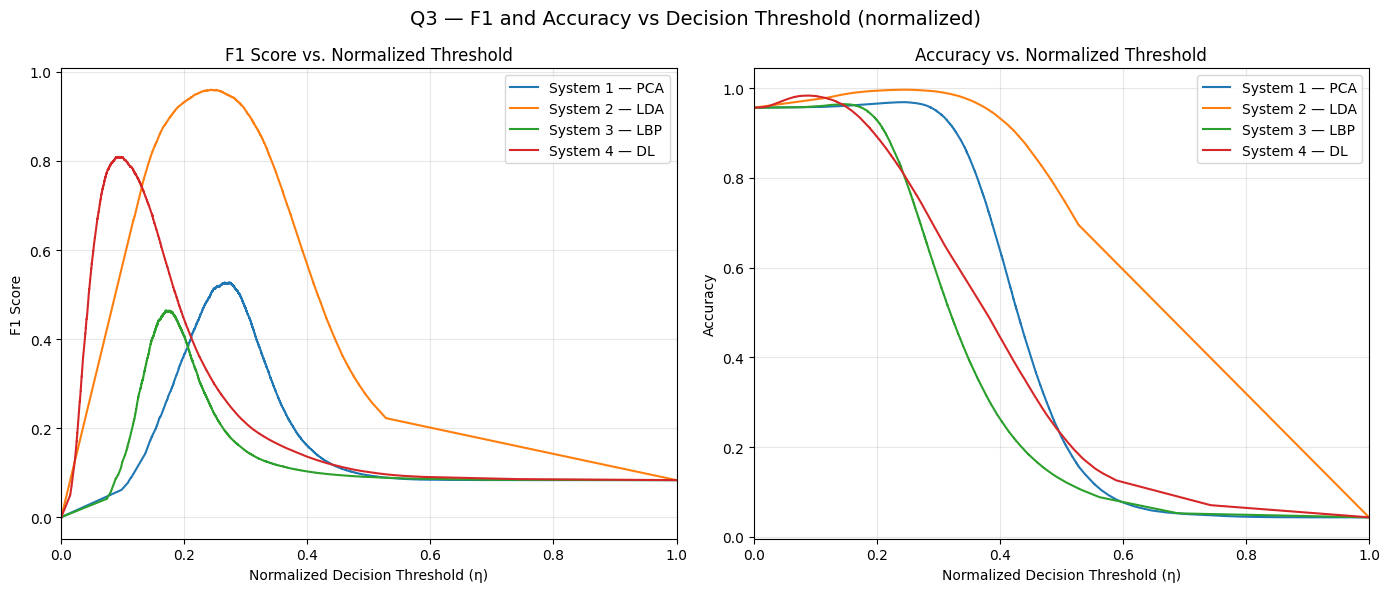

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for genuine_id, scores, name in systems:
    fpr        = roc_data[name]["fpr"]
    tpr        = roc_data[name]["tpr"]
    thresholds = roc_data[name]["thresholds"]

    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall    = tpr
    f1        = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy  = (tpr * P + (1 - fpr) * N) / (P + N)

    # Normalize using only finite values
    finite_mask = np.isfinite(thresholds)
    t_min = thresholds[finite_mask].min()
    t_max = thresholds[finite_mask].max()
    thresholds_clipped = np.clip(thresholds, t_min, t_max)
    thresholds_norm = (thresholds_clipped - t_min) / (t_max - t_min + 1e-10)

    axes[0].plot(thresholds_norm, f1,       label=name)
    axes[1].plot(thresholds_norm, accuracy, label=name)

axes[0].set_title("F1 Score vs. Normalized Threshold")
axes[0].set_xlabel("Normalized Decision Threshold (η)")
axes[0].set_ylabel("F1 Score")
axes[0].set_xlim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Accuracy vs. Normalized Threshold")
axes[1].set_xlabel("Normalized Decision Threshold (η)")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Q3 — F1 and Accuracy vs Decision Threshold (normalized)", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
print("=== Threshold where F1 is maximal ===")
print(f"{'System':>35} {'Threshold':>12} {'Max F1':>12} {'Accuracy':>12}")
print("-" * 75)

for genuine_id, scores, name in systems:
    fpr        = roc_data[name]["fpr"]
    tpr        = roc_data[name]["tpr"]
    thresholds = roc_data[name]["thresholds"]
    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall    = tpr
    f1        = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy  = (tpr * P + (1 - fpr) * N) / (P + N)

    best_idx = np.argmax(f1)
    print(f"{name:>35} {thresholds[best_idx]:>12.4f} {f1[best_idx]:>12.4f} {accuracy[best_idx]:>12.4f}")

=== Threshold where F1 is maximal ===
                             System    Threshold       Max F1     Accuracy
---------------------------------------------------------------------------
                     System 1 — PCA       5.7335       0.5270       0.9662
                     System 2 — LDA      10.4308       0.9598       0.9966
                     System 3 — LBP       5.5730       0.4640       0.9594
                      System 4 — DL      59.3732       0.8093       0.9834


In [19]:
print("=== Threshold where Accuracy is maximal ===")
print(f"{'System':>35} {'Threshold':>12} {'Max Accuracy':>12} {'F1':>12}")
print("-" * 75)

for genuine_id, scores, name in systems:
    fpr        = roc_data[name]["fpr"]
    tpr        = roc_data[name]["tpr"]
    thresholds = roc_data[name]["thresholds"]
    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall    = tpr
    f1        = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy  = (tpr * P + (1 - fpr) * N) / (P + N)

    best_idx = np.argmax(accuracy)
    print(f"{name:>35} {thresholds[best_idx]:>12.4f} {accuracy[best_idx]:>12.4f} {f1[best_idx]:>12.4f}")

=== Threshold where Accuracy is maximal ===
                             System    Threshold Max Accuracy           F1
---------------------------------------------------------------------------
                     System 1 — PCA       5.3914       0.9688       0.5035
                     System 2 — LDA      10.4308       0.9966       0.9598
                     System 3 — LBP       5.3399       0.9644       0.4023
                      System 4 — DL      57.2239       0.9836       0.8073


<div class="alert alert-block alert-success">
<b>Q4: </b> Perform a full-on verification assessment based on the scores obtained. Interpret the results.
</div>

Hint: Calculate and plot the equal error rate. Plot the precision-recall curve and compute AUC and average precision. Interpret the results e.g. by explaining what aspect of the system performance is explored by each metric.

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

print(f"{'System':>35} {'AUC':>12}")
print("-" * 50)

for genuine_id, scores, name in systems:
    auc = roc_auc_score(genuine_id, -scores)  # negative because lower distance = more similar
    print(f"{name:>35} {auc:>12.4f}")

                             System          AUC
--------------------------------------------------
                     System 1 — PCA       0.8113
                     System 2 — LDA       0.9985
                     System 3 — LBP       0.8406
                      System 4 — DL       0.9899


System 1 — PCA: EER = 0.2557 at threshold = 7.4637
System 2 — LDA: EER = 0.0162 at threshold = 13.3304
System 3 — LBP: EER = 0.2438 at threshold = 6.4534
System 4 — DL: EER = 0.0454 at threshold = 98.6434


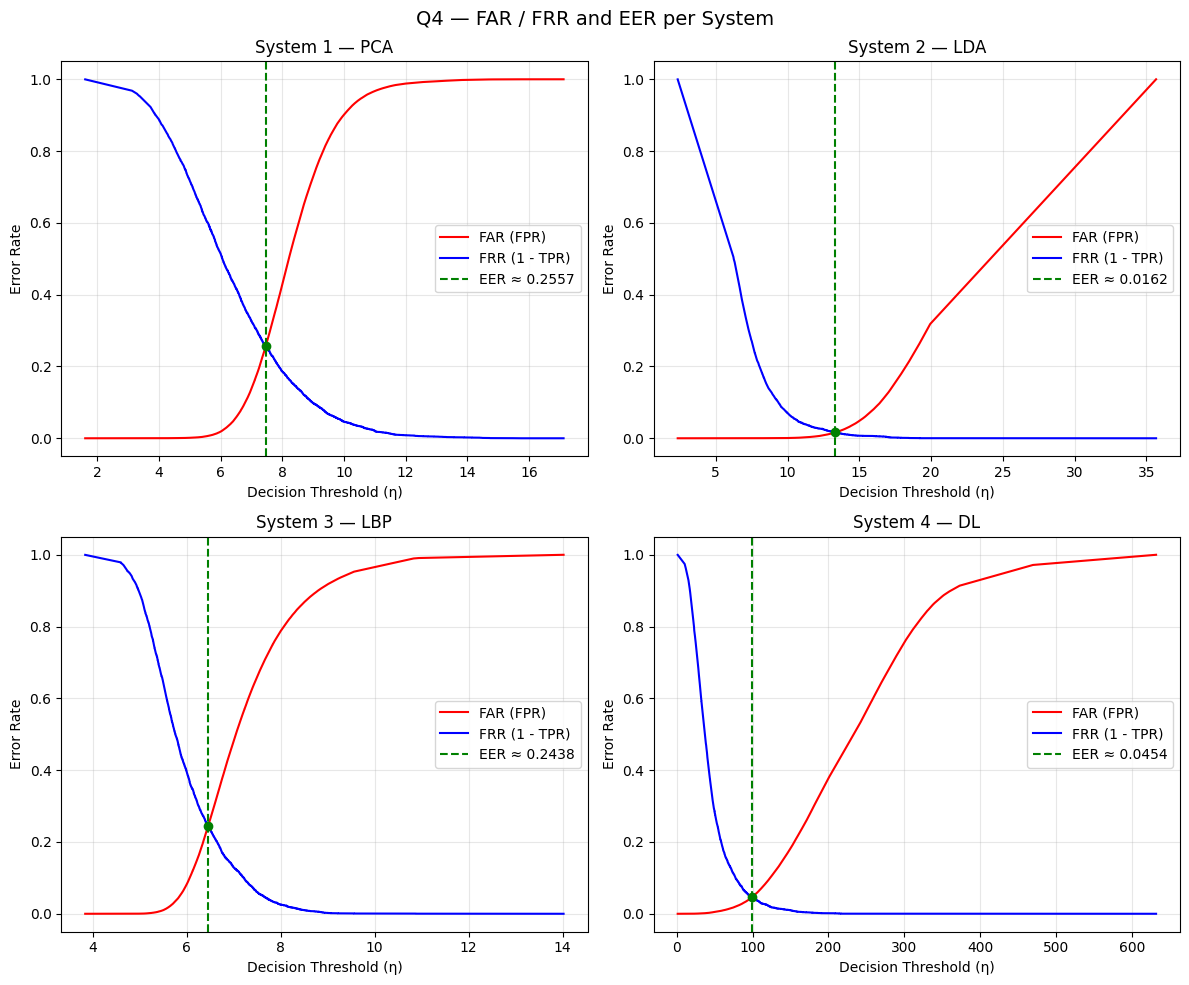

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (genuine_id, scores, name) in enumerate(systems):
    fpr, tpr, thresholds = roc_curve(genuine_id, -scores)  # negative scores
    frr = 1 - tpr

    # Approximate EER
    eer_idx = np.argmin(np.abs(fpr - frr))
    eer = (fpr[eer_idx] + frr[eer_idx]) / 2
    eer_threshold = -thresholds[eer_idx]  # back to original scale

    print(f"{name}: EER = {eer:.4f} at threshold = {eer_threshold:.4f}")

    axes[idx].plot(-thresholds, fpr, color='red',  label='FAR (FPR)')
    axes[idx].plot(-thresholds, frr, color='blue', label='FRR (1 - TPR)')
    axes[idx].axvline(eer_threshold, color='green', linestyle='--', label=f'EER ≈ {eer:.4f}')
    axes[idx].scatter([eer_threshold], [eer], color='green', zorder=5)
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Decision Threshold (η)")
    axes[idx].set_ylabel("Error Rate")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Q4 — FAR / FRR and EER per System", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
print(f"{'System':>35} {'Threshold':>12} {'FAR':>12} {'FRR':>12} {'FAR+FRR':>12}")
print("-" * 80)

for genuine_id, scores, name in systems:
    fpr, tpr, thresholds = roc_curve(genuine_id, -scores)
    frr = 1 - tpr

    min_idx = np.argmin(fpr + frr)
    print(f"{name:>35} {-thresholds[min_idx]:>12.4f} "
          f"{fpr[min_idx]:>12.4f} {frr[min_idx]:>12.4f} "
          f"{(fpr[min_idx] + frr[min_idx]):>12.4f}")

                             System    Threshold          FAR          FRR      FAR+FRR
--------------------------------------------------------------------------------
                     System 1 — PCA       6.8433       0.1068       0.3513       0.4581
                     System 2 — LDA      12.7997       0.0109       0.0204       0.0313
                     System 3 — LBP       6.2360       0.1567       0.3038       0.4605
                      System 4 — DL      98.7049       0.0454       0.0447       0.0901


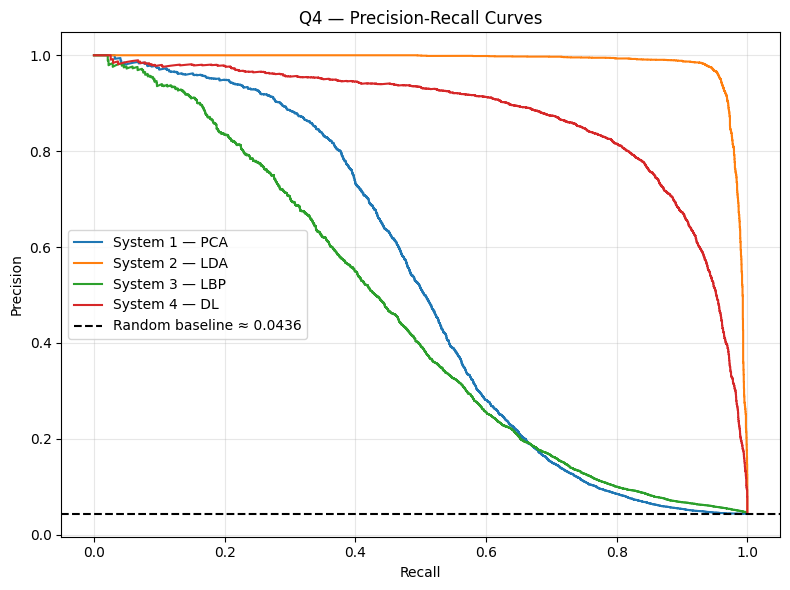


                             System       AUC-PR   Avg Precision
-----------------------------------------------------------------
                     System 1 — PCA       0.5163          0.5164
                     System 2 — LDA       0.9853          0.9853
                     System 3 — LBP       0.4550          0.4550
                      System 4 — DL       0.8708          0.8708


In [23]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for genuine_id, scores, name in systems:
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    ax.plot(recall, precision, label=name)

baseline = np.sum(system1_genuine_id) / len(system1_genuine_id)
ax.axhline(y=baseline, color='black', linestyle='--', 
           label=f'Random baseline ≈ {baseline:.4f}')

ax.set_title("Q4 — Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# AUC-PR
print(f"\n{'System':>35} {'AUC-PR':>12} {'Avg Precision':>15}")
print("-" * 65)

for genuine_id, scores, name in systems:
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    auc_pr = auc(recall, precision)
    ap     = average_precision_score(genuine_id, -scores)
    print(f"{name:>35} {auc_pr:>12.4f} {ap:>15.4f}")

### 2.2. Validation as identification system

<div class="alert alert-block alert-success">
<b>Q5: </b> Validate the systems in an identification scenario.
</div>

Hint: Generate a Cumulative Matching Curve. Calculate and compare rank-1 performance among the four feature extraction techniques.

In [24]:
# CMC expects similarity (higher = more similar), so we negate the distance matrices
system1_similarity_matrix = -dist_matrices['PCA']
system2_similarity_matrix = -dist_matrices['LDA']
system3_similarity_matrix = -dist_matrices['LBP']
system4_similarity_matrix = -dist_matrices['DL']

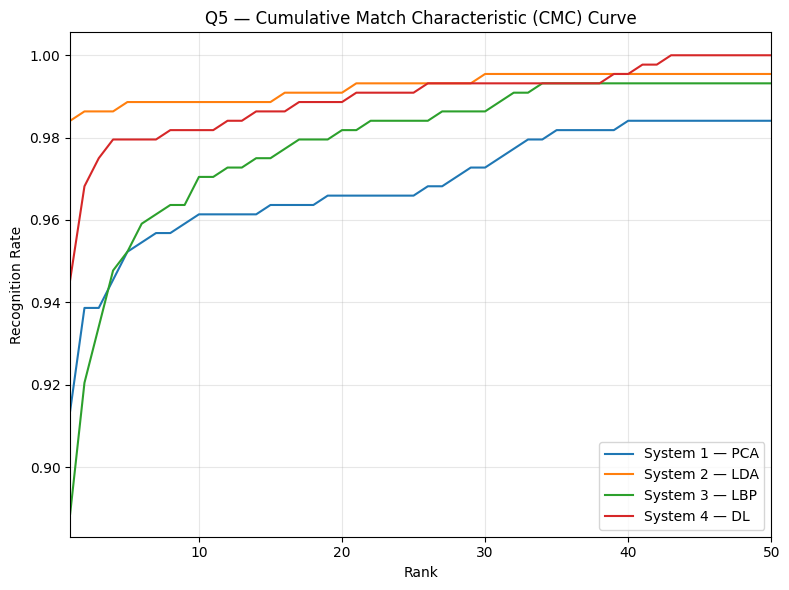

                             System  Rank-1 Rate
--------------------------------------------------
                     System 1 — PCA       0.9136
                     System 2 — LDA       0.9841
                     System 3 — LBP       0.8886
                      System 4 — DL       0.9455


In [25]:
def compute_cmc(similarity_matrix):
    n = similarity_matrix.shape[0]
    ranks = np.zeros(n, dtype=int)
    
    for i in range(n):
        row = similarity_matrix[i].copy()
        row[i] = -np.inf  # exclude self-comparison
        sorted_indices = np.argsort(row)[::-1]
        # find where the correct identity lands
        correct_label = labels[i]
        for rank, idx in enumerate(sorted_indices):
            if labels[idx] == correct_label:
                ranks[i] = rank + 1  # rank starts at 1
                break
    
    cmc = np.array([np.sum(ranks <= k) / n for k in range(1, n + 1)])
    return cmc

fig, ax = plt.subplots(figsize=(8, 6))

systems_cmc = [
    (system1_similarity_matrix, "System 1 — PCA"),
    (system2_similarity_matrix, "System 2 — LDA"),
    (system3_similarity_matrix, "System 3 — LBP"),
    (system4_similarity_matrix, "System 4 — DL"),
]

for sim_matrix, name in systems_cmc:
    cmc = compute_cmc(np.array(sim_matrix))
    ax.plot(range(1, len(cmc) + 1), cmc, label=name)

ax.set_title("Q5 — Cumulative Match Characteristic (CMC) Curve")
ax.set_xlabel("Rank")
ax.set_ylabel("Recognition Rate")
ax.set_xlim(1, 50)  # zoom in on the interesting part
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Rank-1
print(f"{'System':>35} {'Rank-1 Rate':>12}")
print("-" * 50)

for sim_matrix, name in systems_cmc:
    cmc = compute_cmc(np.array(sim_matrix))
    print(f"{name:>35} {cmc[0]:>12.4f}")

<div class="alert alert-block alert-success">
<b>Q6: </b> Fine-tune your model for feature extraction
</div>

Hint: Tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. For PCA, LDA and DL using Siamese Networks, assess the dimension of latent representations (num_components). For LBP, examine the radius. You can use default values for other parameters as provided. In your report, please explain the effect of these hyperparameters on model performance using 2 implemented evaluation metrics of your choice from Questions 3-5, and provide reasoning for their impact.

In [29]:
from sklearn.metrics import precision_recall_curve, auc

def compute_auc_pr(dist_matrix, labels):
    genuine_id, scores = get_genuine_id_scores(dist_matrix, labels)
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    return auc(recall, precision)

def compute_rank1(dist_matrix, labels):
    n = len(labels)
    correct = 0
    for i in range(n):
        row = dist_matrix[i].copy()
        row[i] = np.inf
        sorted_indices = np.argsort(row)
        if labels[sorted_indices[0]] == labels[i]:
            correct += 1
    return correct / n

def get_genuine_id_scores(dist_matrix, labels):
    n = len(labels)
    genuine_id, scores = [], []
    for i in range(n):
        for j in range(i + 1, n):
            scores.append(dist_matrix[i, j])
            genuine_id.append(1 if labels[i] == labels[j] else 0)
    return np.array(genuine_id), np.array(scores)

def compute_auc_pr(dist_matrix, labels):
    genuine_id, scores = get_genuine_id_scores(dist_matrix, labels)
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    return auc(recall, precision)

In [40]:
pca_components = [10, 15, 18, 20, 22, 25, 30, 35]
pca_rank1, pca_aucpr = [], []

for n_comp in pca_components:
    n_comp = min(n_comp, min(n_samples, n_features))
    desc   = PCA(n_components=n_comp, svd_solver='randomized', whiten=True).fit(faces.data)
    emb    = desc.transform(faces.data)
    D      = compute_distance_matrix(emb, euclidean)
    pca_rank1.append(compute_rank1(D, faces.labels))
    pca_aucpr.append(compute_auc_pr(D, faces.labels))
    print(f"PCA n_components={n_comp:>4} | Rank-1={pca_rank1[-1]:.4f} | AUC-PR={pca_aucpr[-1]:.4f}")

PCA n_components=  10 | Rank-1=0.7614 | AUC-PR=0.3813
PCA n_components=  15 | Rank-1=0.8795 | AUC-PR=0.5403
PCA n_components=  18 | Rank-1=0.8659 | AUC-PR=0.5639
PCA n_components=  20 | Rank-1=0.8932 | AUC-PR=0.5713
PCA n_components=  22 | Rank-1=0.8841 | AUC-PR=0.5511
PCA n_components=  25 | Rank-1=0.9000 | AUC-PR=0.5690
PCA n_components=  30 | Rank-1=0.9068 | AUC-PR=0.5414
PCA n_components=  35 | Rank-1=0.9136 | AUC-PR=0.5174


In [51]:
lda_components = [5, 10, 15, 20, 25]
lda_rank1, lda_aucpr = [], []

for n_comp in lda_components:
    n_comp = min(n_comp, n_classes - 1)
    desc   = LinearDiscriminantAnalysis(n_components=n_comp).fit(faces.data, faces.target)
    emb    = desc.transform(faces.data)
    D      = compute_distance_matrix(emb, euclidean)
    lda_rank1.append(compute_rank1(D, faces.labels))
    lda_aucpr.append(compute_auc_pr(D, faces.labels))
    print(f"LDA n_components={n_comp:>4} | Rank-1={lda_rank1[-1]:.4f} | AUC-PR={lda_aucpr[-1]:.4f}")

LDA n_components=   5 | Rank-1=0.9023 | AUC-PR=0.7955
LDA n_components=  10 | Rank-1=0.9795 | AUC-PR=0.9504
LDA n_components=  15 | Rank-1=0.9795 | AUC-PR=0.9733
LDA n_components=  20 | Rank-1=0.9841 | AUC-PR=0.9844
LDA n_components=  25 | Rank-1=0.9841 | AUC-PR=0.9853


In [31]:
lbp_radii = [1, 2, 3, 4, 5]
lbp_rank1, lbp_aucpr = [], []

for r in lbp_radii:
    desc = LBP(numPoints=8, radius=r, grid_x=7, grid_y=7)
    emb  = desc.describe_list(faces.images[..., 0])
    D    = compute_distance_matrix(emb, CHI2)
    lbp_rank1.append(compute_rank1(D, faces.labels))
    lbp_aucpr.append(compute_auc_pr(D, faces.labels))
    print(f"LBP radius={r} | Rank-1={lbp_rank1[-1]:.4f} | AUC-PR={lbp_aucpr[-1]:.4f}")

LBP radius=1 | Rank-1=0.8886 | AUC-PR=0.4550
LBP radius=2 | Rank-1=0.9545 | AUC-PR=0.7160
LBP radius=3 | Rank-1=0.9591 | AUC-PR=0.7610
LBP radius=4 | Rank-1=0.9636 | AUC-PR=0.7443
LBP radius=5 | Rank-1=0.9614 | AUC-PR=0.7223


In [32]:
dl_sizes  = [16, 32, 64, 128, 256]
dl_rank1, dl_aucpr = [], []

for emb_size in dl_sizes:
    print(f"\n── Training Siamese with embedding_size={emb_size} ──")
    enc, mdl = siamese.create_siamese_model(imshape, emb_size)
    x_tr, x_te, y_tr, y_te = holdout_split(
        *siamese.get_siamese_paired_data(faces.images, faces.target))
    mdl.compile(loss=siamese.contrastive_loss, optimizer=Adam(),
                metrics=[siamese.accuracy], run_eagerly=True)
    mdl.fit([x_tr[:, 0], x_tr[:, 1]], y_tr,
            validation_split=0.2, batch_size=32, verbose=0, epochs=10)
    emb  = enc(faces.images.astype(np.float32)).numpy()
    D    = compute_distance_matrix(emb, euclidean)
    dl_rank1.append(compute_rank1(D, faces.labels))
    dl_aucpr.append(compute_auc_pr(D, faces.labels))
    print(f"DL embedding_size={emb_size} | Rank-1={dl_rank1[-1]:.4f} | AUC-PR={dl_aucpr[-1]:.4f}")


── Training Siamese with embedding_size=16 ──


2026-05-07 10:03:38.461061: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.
2026-05-07 10:03:38.642336: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.


DL embedding_size=16 | Rank-1=0.8068 | AUC-PR=0.5625

── Training Siamese with embedding_size=32 ──
DL embedding_size=32 | Rank-1=0.9886 | AUC-PR=0.9104

── Training Siamese with embedding_size=64 ──
DL embedding_size=64 | Rank-1=0.9909 | AUC-PR=0.9737

── Training Siamese with embedding_size=128 ──
DL embedding_size=128 | Rank-1=0.9864 | AUC-PR=0.9821

── Training Siamese with embedding_size=256 ──
DL embedding_size=256 | Rank-1=0.9932 | AUC-PR=0.9830


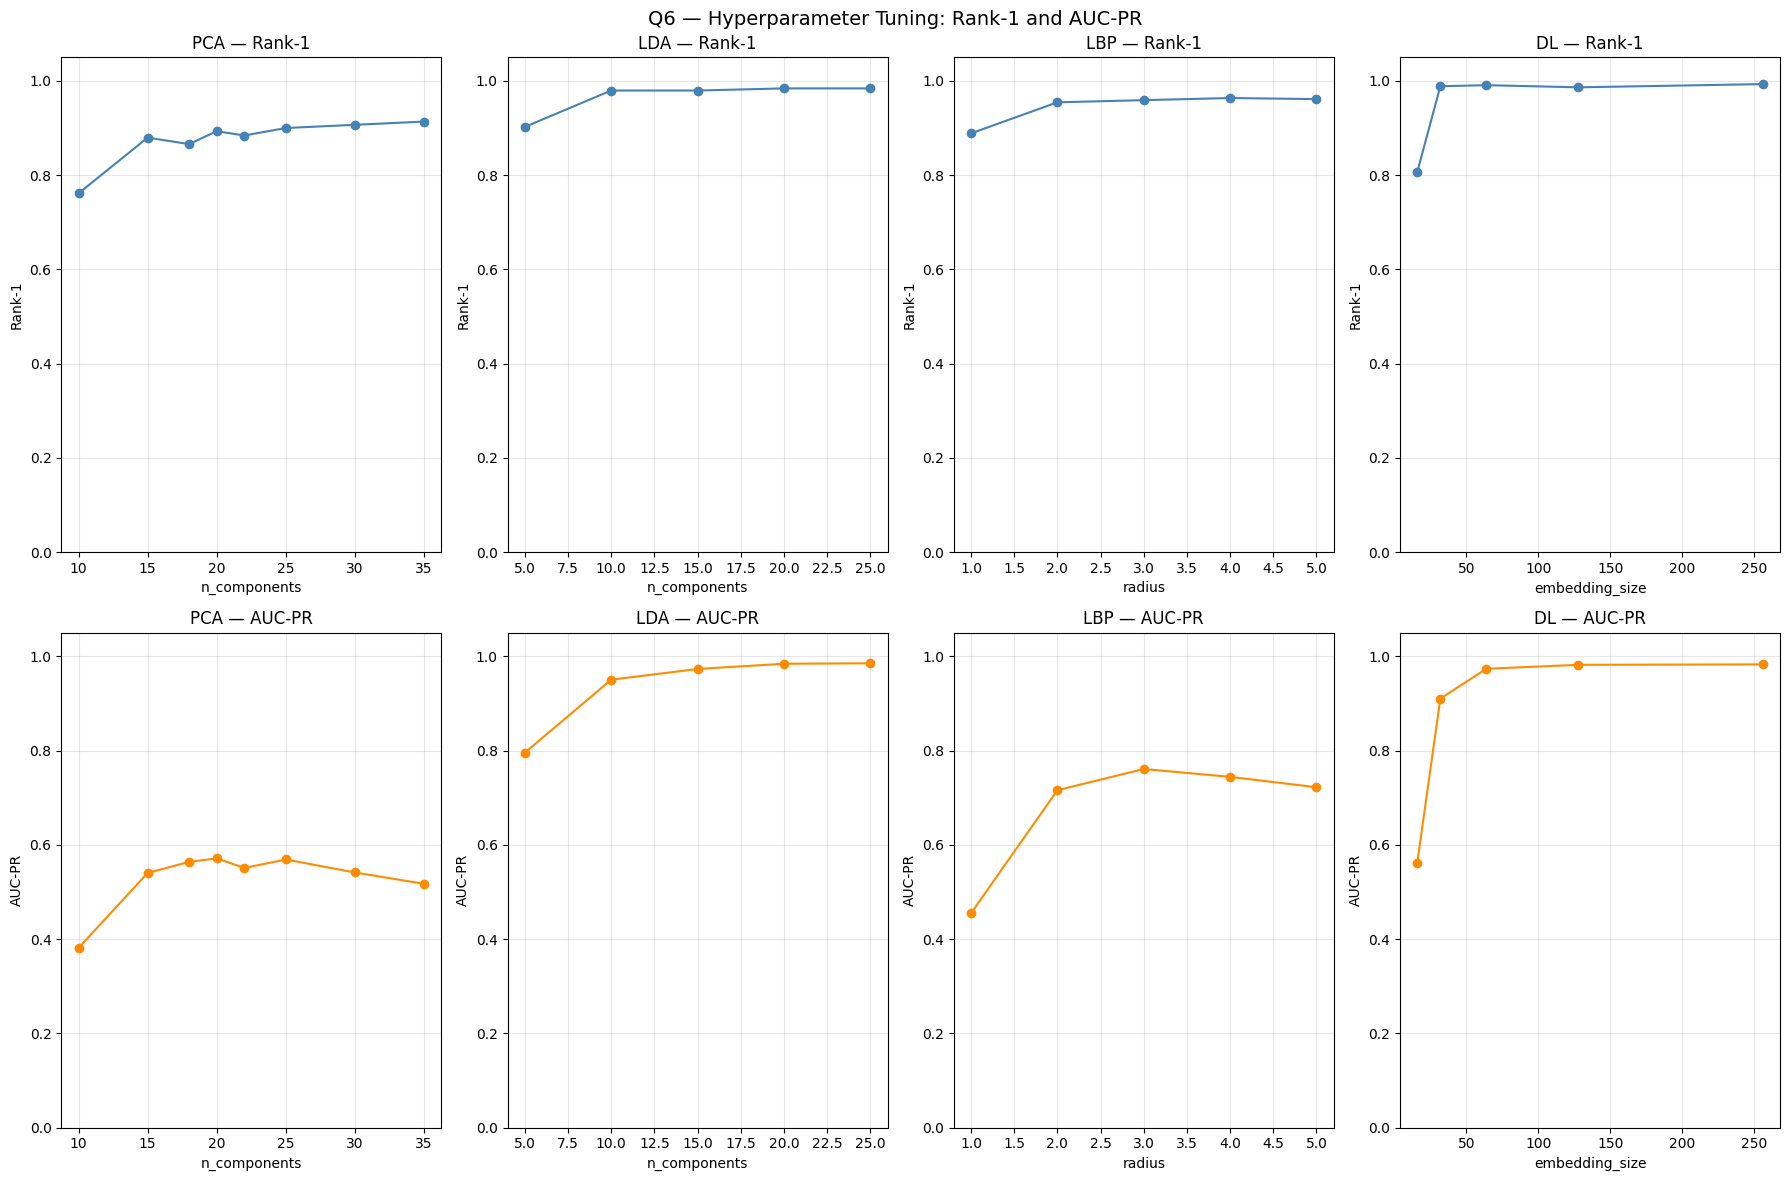

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))

configs = [
    ("PCA", "n_components", pca_components, pca_rank1, pca_aucpr),
    ("LDA", "n_components", lda_components, lda_rank1, lda_aucpr),
    ("LBP", "radius",       lbp_radii,      lbp_rank1, lbp_aucpr),
    ("DL",  "embedding_size", dl_sizes,     dl_rank1,  dl_aucpr),
]

for col, (name, param_name, param_vals, rank1s, aucprs) in enumerate(configs):
    axes[0, col].plot(param_vals, rank1s, marker='o', color='steelblue')
    axes[0, col].set_title(f"{name} — Rank-1")
    axes[0, col].set_xlabel(param_name)
    axes[0, col].set_ylabel("Rank-1")
    axes[0, col].set_ylim(0.0, 1.05)
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(param_vals, aucprs, marker='o', color='darkorange')
    axes[1, col].set_title(f"{name} — AUC-PR")
    axes[1, col].set_xlabel(param_name)
    axes[1, col].set_ylabel("AUC-PR")
    axes[1, col].set_ylim(0.0, 1.05)
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle("Q6 — Hyperparameter Tuning: Rank-1 and AUC-PR", fontsize=14)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Q7: </b> Compare the 4 feature extraction models (LBP, PCA, LDA, DL using Siamese Networks)
</div>

Hint: Report on the performance using the implemented evaluation metrics from Questions 2-5. Perform the comparison among models under optimal hyperparameter settings as determined in Question 6

In [55]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

def get_scores(dist_matrix, labels):
    n = len(labels)
    genuine, impostor = [], []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                genuine.append(dist_matrix[i, j])
            else:
                impostor.append(dist_matrix[i, j])
    return np.array(genuine), np.array(impostor)

def get_genuine_id_scores(dist_matrix, labels):
    n = len(labels)
    genuine_id, scores = [], []
    for i in range(n):
        for j in range(i + 1, n):
            scores.append(dist_matrix[i, j])
            genuine_id.append(1 if labels[i] == labels[j] else 0)
    return np.array(genuine_id), np.array(scores)

def compute_rank1(dist_matrix, labels):
    n = len(labels)
    correct = 0
    for i in range(n):
        row = dist_matrix[i].copy()
        row[i] = np.inf
        if labels[np.argsort(row)[0]] == labels[i]:
            correct += 1
    return correct / n

def compute_cmc(dist_matrix, labels):
    n = len(labels)
    max_rank = n - 1
    cmc = np.zeros(max_rank)
    for i in range(n):
        row = dist_matrix[i].copy()
        row[i] = np.inf
        sorted_idx = np.argsort(row)
        for rank in range(max_rank):
            if labels[sorted_idx[rank]] == labels[i]:
                cmc[rank:] += 1
                break
    return cmc / n

def compute_eer(fpr, tpr, thresholds):
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2, thresholds[idx]

def compute_f1_accuracy_curve(dist_matrix, labels):
    from sklearn.metrics import f1_score, accuracy_score
    genuine_id, scores = get_genuine_id_scores(dist_matrix, labels)
    thresholds = np.linspace(scores.min(), scores.max(), 200)
    f1s, accs = [], []
    for t in thresholds:
        preds = (scores <= t).astype(int)
        f1s.append(f1_score(genuine_id, preds, zero_division=0))
        accs.append(accuracy_score(genuine_id, preds))
    f1s, accs = np.array(f1s), np.array(accs)
    best_t = thresholds[np.argmax(f1s)]
    return thresholds, f1s, accs, best_t

In [53]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from localmodules.local_binary_patterns import LBP
import localmodules.siamese as siamese
from tensorflow.keras.optimizers import Adam
from scipy.spatial.distance import euclidean

# ── PCA (optimal: n_components=25) ───────────────────────────────────────────
pca_opt = PCA(n_components=25, svd_solver='randomized', whiten=True).fit(faces.data)
emb_pca_opt = pca_opt.transform(faces.data)
dist_pca_opt = compute_distance_matrix(emb_pca_opt, euclidean)
print("PCA done")

# ── LDA (optimal: n_components=25) ───────────────────────────────────────────
lda_opt = LinearDiscriminantAnalysis(n_components=25).fit(faces.data, faces.target)
emb_lda_opt = lda_opt.transform(faces.data)
dist_lda_opt = compute_distance_matrix(emb_lda_opt, euclidean)
print("LDA done")

# ── LBP (optimal: radius=3) ───────────────────────────────────────────────────
lbp_opt = LBP(numPoints=8, radius=3, grid_x=7, grid_y=7)
emb_lbp_opt = lbp_opt.describe_list(faces.images[..., 0])
dist_lbp_opt = compute_distance_matrix(emb_lbp_opt, CHI2)
print("LBP done")

# ── DL (optimal: embedding_size=64) ──────────────────────────────────────────
encoder_opt, model_opt = siamese.create_siamese_model(imshape, 64)
x_train, x_test, y_train, y_test = holdout_split(
    *siamese.get_siamese_paired_data(faces.images, faces.target))
model_opt.compile(loss=siamese.contrastive_loss, optimizer=Adam(),
                  metrics=[siamese.accuracy], run_eagerly=True)
model_opt.fit([x_train[:, 0], x_train[:, 1]], y_train,
              validation_split=0.2, batch_size=32, verbose=2, epochs=10)
emb_dl_opt = encoder_opt(faces.images.astype(np.float32)).numpy()
dist_dl_opt = compute_distance_matrix(emb_dl_opt, euclidean)
print("DL done")

# ── Optimal systems list ──────────────────────────────────────────────────────
systems_opt = [
    ('PCA (n=25)',   dist_pca_opt),
    ('LDA (n=25)',   dist_lda_opt),
    ('LBP (r=3)',    dist_lbp_opt),
    ('DL (emb=64)',  dist_dl_opt),
]
print("All optimal models ready!")

PCA done
LDA done
LBP done
Epoch 1/10
38/38 - 8s - loss: 0.1165 - accuracy: 0.6620 - val_loss: 0.0636 - val_accuracy: 0.8198 - 8s/epoch - 212ms/step
Epoch 2/10
38/38 - 6s - loss: 0.0460 - accuracy: 0.9046 - val_loss: 0.0379 - val_accuracy: 0.9250 - 6s/epoch - 171ms/step
Epoch 3/10
38/38 - 6s - loss: 0.0295 - accuracy: 0.9539 - val_loss: 0.0258 - val_accuracy: 0.9750 - 6s/epoch - 170ms/step
Epoch 4/10
38/38 - 6s - loss: 0.0185 - accuracy: 0.9860 - val_loss: 0.0198 - val_accuracy: 0.9937 - 6s/epoch - 169ms/step
Epoch 5/10
38/38 - 8s - loss: 0.0120 - accuracy: 0.9967 - val_loss: 0.0166 - val_accuracy: 0.9906 - 8s/epoch - 211ms/step
Epoch 6/10
38/38 - 7s - loss: 0.0096 - accuracy: 0.9967 - val_loss: 0.0135 - val_accuracy: 0.9969 - 7s/epoch - 186ms/step
Epoch 7/10
38/38 - 8s - loss: 0.0070 - accuracy: 0.9975 - val_loss: 0.0131 - val_accuracy: 0.9906 - 8s/epoch - 211ms/step
Epoch 8/10
38/38 - 11s - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.0120 - val_accuracy: 0.9937 - 11s/epoch - 286ms/

In [58]:
labels = np.array(faces.target)

system1_genuine_id_opt, system1_scores_opt = extract_scores(dist_pca_opt, labels)
system2_genuine_id_opt, system2_scores_opt = extract_scores(dist_lda_opt, labels)
system3_genuine_id_opt, system3_scores_opt = extract_scores(dist_lbp_opt, labels)
system4_genuine_id_opt, system4_scores_opt = extract_scores(dist_dl_opt,  labels)

systems_opt = [
    (system1_genuine_id_opt, system1_scores_opt, "System 1 — PCA (n=25)"),
    (system2_genuine_id_opt, system2_scores_opt, "System 2 — LDA (n=25)"),
    (system3_genuine_id_opt, system3_scores_opt, "System 3 — LBP (r=3)"),
    (system4_genuine_id_opt, system4_scores_opt, "System 4 — DL (emb=64)"),
]

for genuine_id, scores, name in systems_opt:
    print(f"{name} | total pairs: {len(scores)} | genuine: {genuine_id.sum()} | impostor: {(genuine_id==0).sum()}")

System 1 — PCA (n=25) | total pairs: 96580 | genuine: 4210 | impostor: 92370
System 2 — LDA (n=25) | total pairs: 96580 | genuine: 4210 | impostor: 92370
System 3 — LBP (r=3) | total pairs: 96580 | genuine: 4210 | impostor: 92370
System 4 — DL (emb=64) | total pairs: 96580 | genuine: 4210 | impostor: 92370


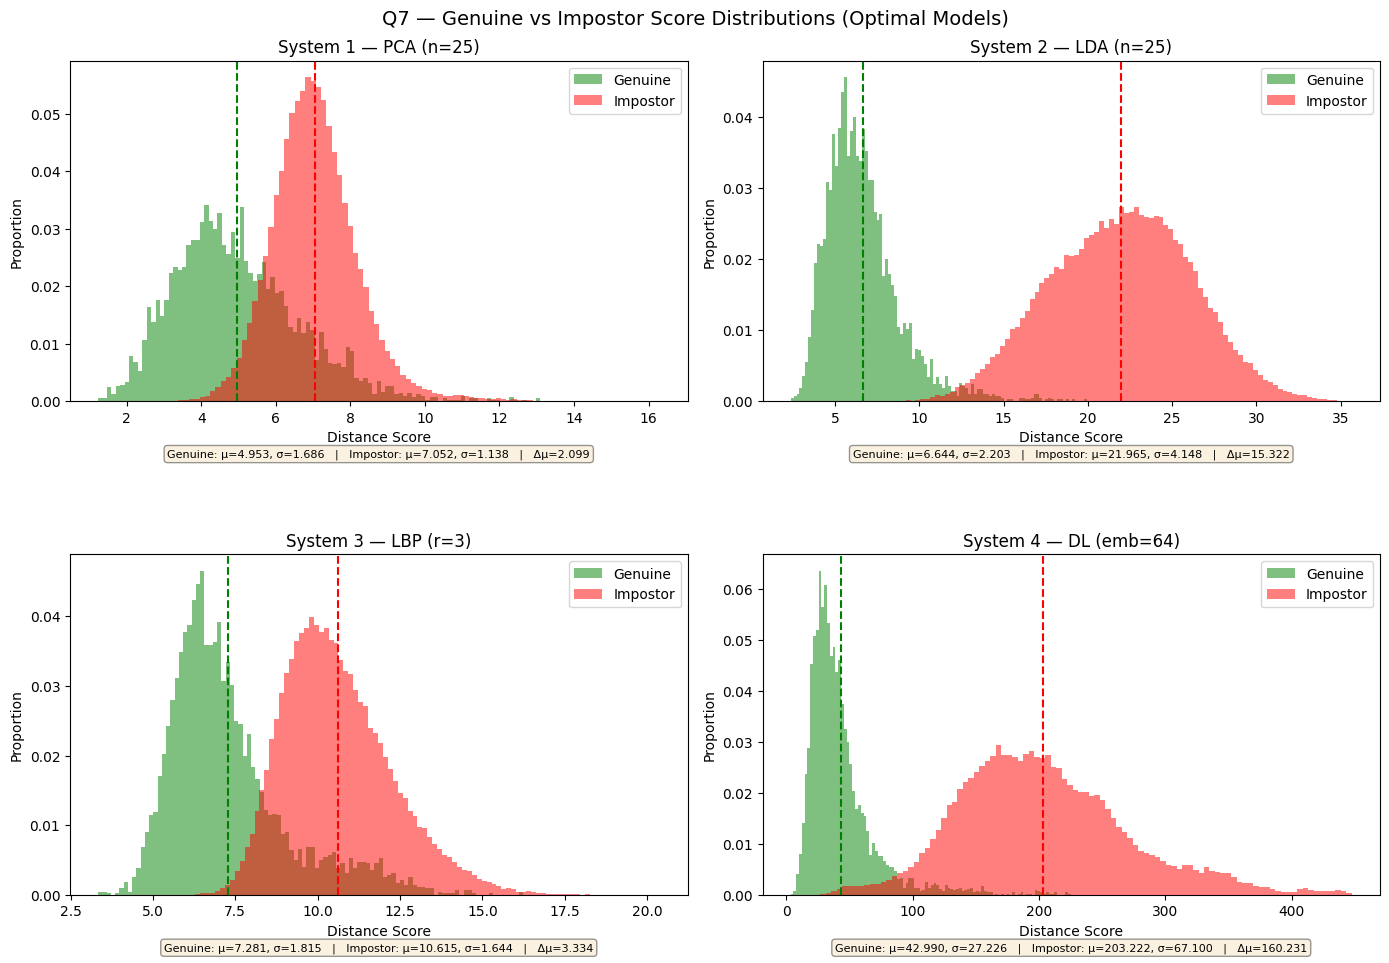

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (genuine_id, scores, name) in enumerate(systems_opt):
    ax = axes[idx]

    genuine_scores  = scores[genuine_id == 1]
    impostor_scores = scores[genuine_id == 0]

    ax.hist(genuine_scores,  bins=100, alpha=0.5, label="Genuine",  color="green",
            weights=np.ones_like(genuine_scores)  / len(genuine_scores))
    ax.hist(impostor_scores, bins=100, alpha=0.5, label="Impostor", color="red",
            weights=np.ones_like(impostor_scores) / len(impostor_scores))

    ax.axvline(genuine_scores.mean(),  color="green", linestyle="--", linewidth=1.5)
    ax.axvline(impostor_scores.mean(), color="red",   linestyle="--", linewidth=1.5)

    ax.set_title(name)
    ax.set_xlabel("Distance Score")
    ax.set_ylabel("Proportion")
    ax.legend()

    stats_text = (
        f"Genuine: μ={genuine_scores.mean():.3f}, σ={genuine_scores.std():.3f}   |   "
        f"Impostor: μ={impostor_scores.mean():.3f}, σ={impostor_scores.std():.3f}   |   "
        f"Δμ={impostor_scores.mean() - genuine_scores.mean():.3f}"
    )
    ax.text(0.5, -0.14, stats_text, transform=ax.transAxes,
            fontsize=8, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle("Q7 — Genuine vs Impostor Score Distributions (Optimal Models)", fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.subplots_adjust(hspace=0.45)
plt.show()

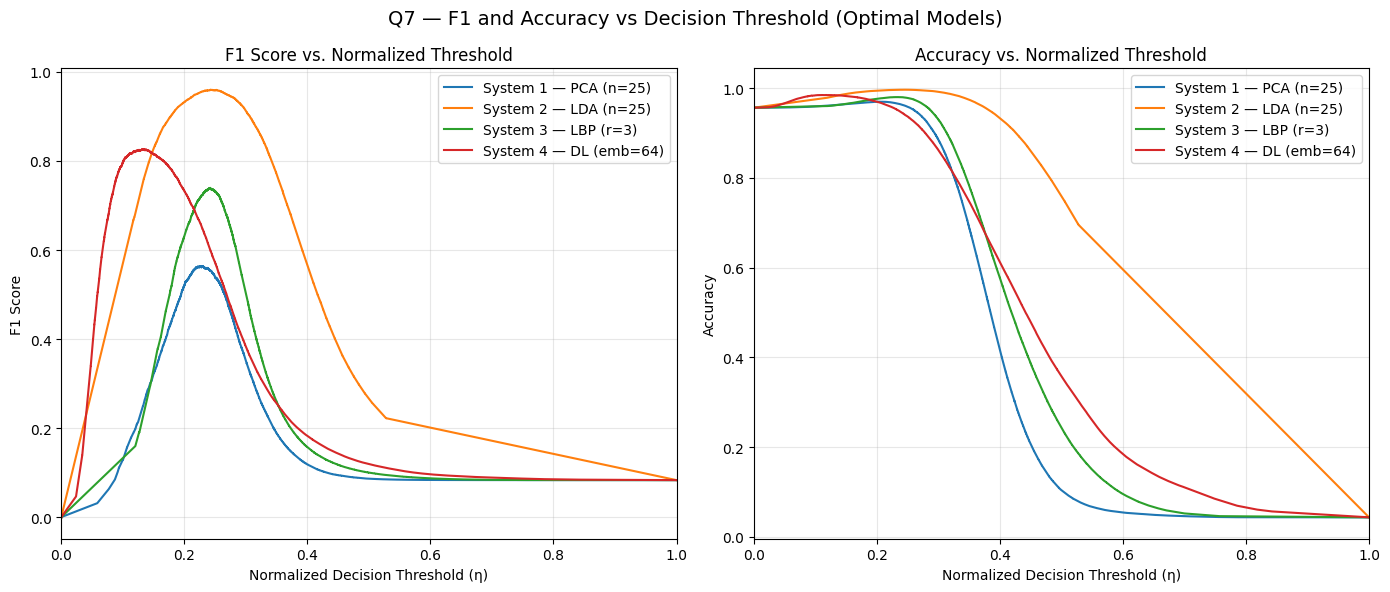

=== Threshold where F1 is maximal ===
                             System    Threshold       Max F1     Accuracy
---------------------------------------------------------------------------
              System 1 — PCA (n=25)       4.6765       0.5636       0.9671
              System 2 — LDA (n=25)      10.4308       0.9598       0.9966
               System 3 — LBP (r=3)       7.4629       0.7395       0.9798
             System 4 — DL (emb=64)      62.9974       0.8260       0.9842


In [60]:
roc_data_opt = {}
for genuine_id, scores, name in systems_opt:
    fpr, tpr, thresholds = roc_curve(genuine_id, -scores)
    roc_data_opt[name] = {"fpr": fpr, "tpr": tpr, "thresholds": -thresholds}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for genuine_id, scores, name in systems_opt:
    fpr        = roc_data_opt[name]["fpr"]
    tpr        = roc_data_opt[name]["tpr"]
    thresholds = roc_data_opt[name]["thresholds"]

    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall    = tpr
    f1        = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy  = (tpr * P + (1 - fpr) * N) / (P + N)

    finite_mask = np.isfinite(thresholds)
    t_min = thresholds[finite_mask].min()
    t_max = thresholds[finite_mask].max()
    thresholds_clipped = np.clip(thresholds, t_min, t_max)
    thresholds_norm = (thresholds_clipped - t_min) / (t_max - t_min + 1e-10)

    axes[0].plot(thresholds_norm, f1,       label=name)
    axes[1].plot(thresholds_norm, accuracy, label=name)

axes[0].set_title("F1 Score vs. Normalized Threshold")
axes[0].set_xlabel("Normalized Decision Threshold (η)")
axes[0].set_ylabel("F1 Score")
axes[0].set_xlim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Accuracy vs. Normalized Threshold")
axes[1].set_xlabel("Normalized Decision Threshold (η)")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Q7 — F1 and Accuracy vs Decision Threshold (Optimal Models)", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Threshold where F1 is maximal ===")
print(f"{'System':>35} {'Threshold':>12} {'Max F1':>12} {'Accuracy':>12}")
print("-" * 75)

for genuine_id, scores, name in systems_opt:
    fpr        = roc_data_opt[name]["fpr"]
    tpr        = roc_data_opt[name]["tpr"]
    thresholds = roc_data_opt[name]["thresholds"]
    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall    = tpr
    f1        = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy  = (tpr * P + (1 - fpr) * N) / (P + N)

    best_idx = np.argmax(f1)
    print(f"{name:>35} {thresholds[best_idx]:>12.4f} {f1[best_idx]:>12.4f} {accuracy[best_idx]:>12.4f}")

                             System          AUC
--------------------------------------------------
              System 1 — PCA (n=25)       0.8538
              System 2 — LDA (n=25)       0.9985
               System 3 — LBP (r=3)       0.9109
             System 4 — DL (emb=64)       0.9892
System 1 — PCA (n=25): EER = 0.2119 at threshold = 6.1885
System 2 — LDA (n=25): EER = 0.0162 at threshold = 13.3304
System 3 — LBP (r=3): EER = 0.1485 at threshold = 8.9681
System 4 — DL (emb=64): EER = 0.0407 at threshold = 101.8637


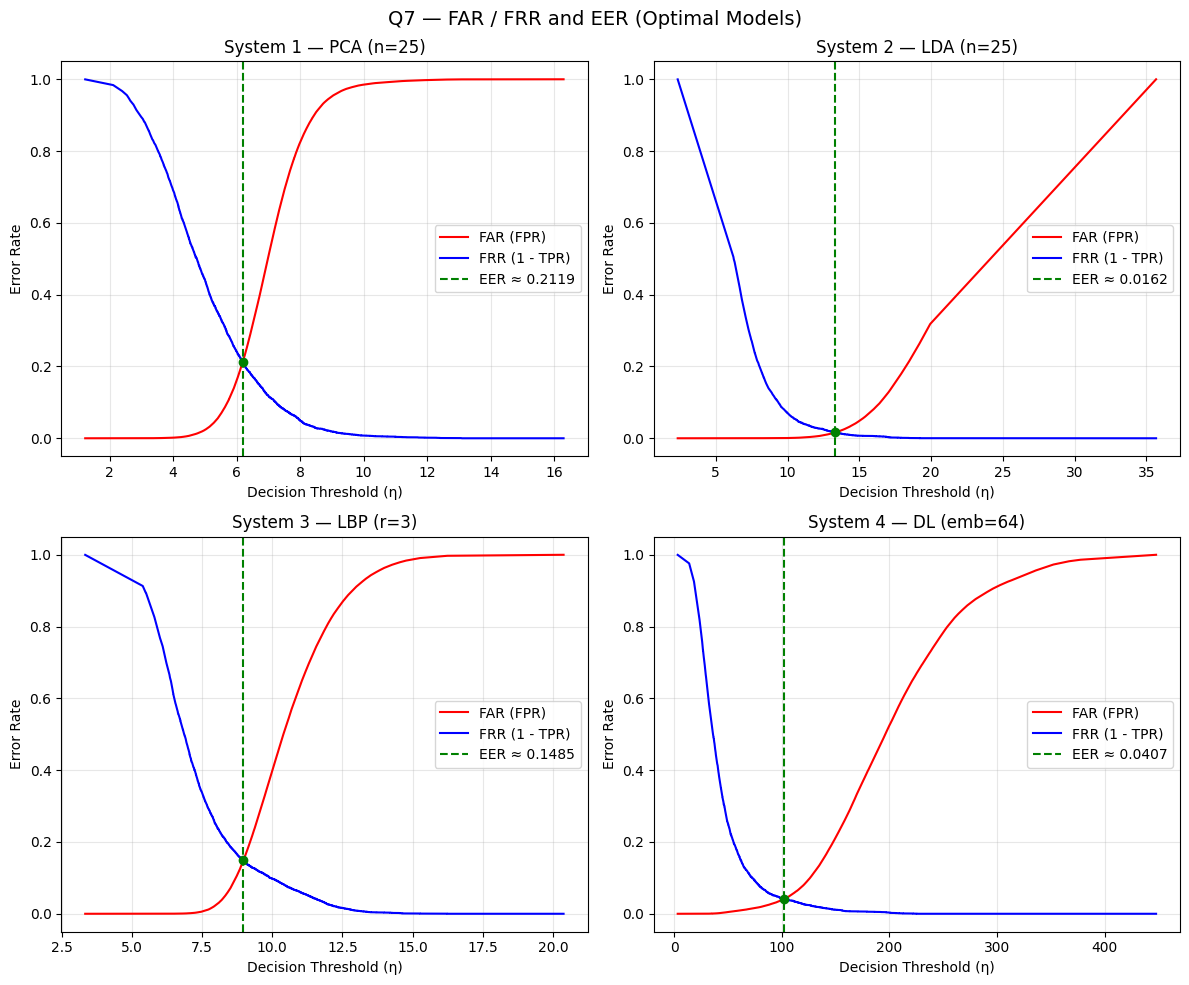

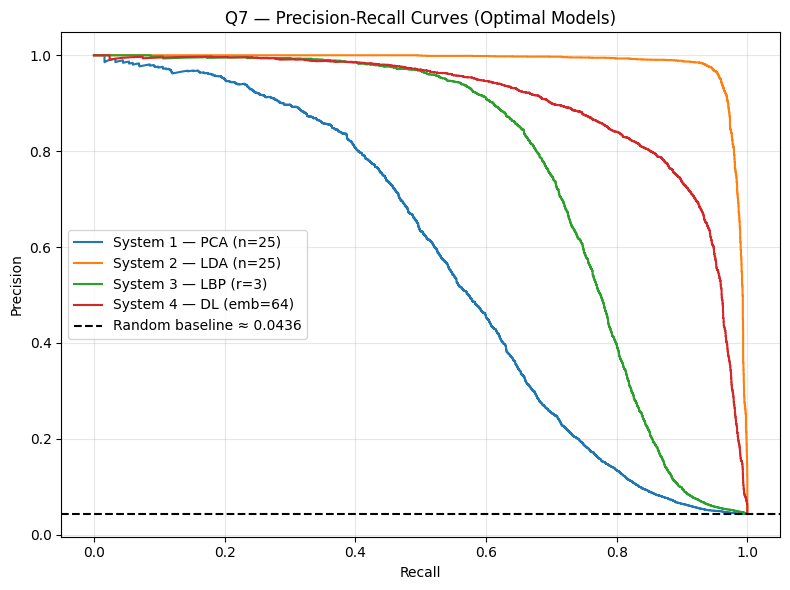


                             System       AUC-PR   Avg Precision
-----------------------------------------------------------------
              System 1 — PCA (n=25)       0.5691          0.5691
              System 2 — LDA (n=25)       0.9853          0.9853
               System 3 — LBP (r=3)       0.7610          0.7610
             System 4 — DL (emb=64)       0.9015          0.9015


In [61]:
print(f"{'System':>35} {'AUC':>12}")
print("-" * 50)

for genuine_id, scores, name in systems_opt:
    auc_score = roc_auc_score(genuine_id, -scores)
    print(f"{name:>35} {auc_score:>12.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (genuine_id, scores, name) in enumerate(systems_opt):
    fpr, tpr, thresholds = roc_curve(genuine_id, -scores)
    frr = 1 - tpr

    eer_idx = np.argmin(np.abs(fpr - frr))
    eer = (fpr[eer_idx] + frr[eer_idx]) / 2
    eer_threshold = -thresholds[eer_idx]

    print(f"{name}: EER = {eer:.4f} at threshold = {eer_threshold:.4f}")

    axes[idx].plot(-thresholds, fpr, color='red',  label='FAR (FPR)')
    axes[idx].plot(-thresholds, frr, color='blue', label='FRR (1 - TPR)')
    axes[idx].axvline(eer_threshold, color='green', linestyle='--', label=f'EER ≈ {eer:.4f}')
    axes[idx].scatter([eer_threshold], [eer], color='green', zorder=5)
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Decision Threshold (η)")
    axes[idx].set_ylabel("Error Rate")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Q7 — FAR / FRR and EER (Optimal Models)", fontsize=14)
plt.tight_layout()
plt.show()

# Precision-Recall
fig, ax = plt.subplots(figsize=(8, 6))

for genuine_id, scores, name in systems_opt:
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    ax.plot(recall, precision, label=name)

baseline = system1_genuine_id_opt.sum() / len(system1_genuine_id_opt)
ax.axhline(y=baseline, color='black', linestyle='--',
           label=f'Random baseline ≈ {baseline:.4f}')

ax.set_title("Q7 — Precision-Recall Curves (Optimal Models)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'System':>35} {'AUC-PR':>12} {'Avg Precision':>15}")
print("-" * 65)

for genuine_id, scores, name in systems_opt:
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    auc_pr = auc(recall, precision)
    ap     = average_precision_score(genuine_id, -scores)
    print(f"{name:>35} {auc_pr:>12.4f} {ap:>15.4f}")

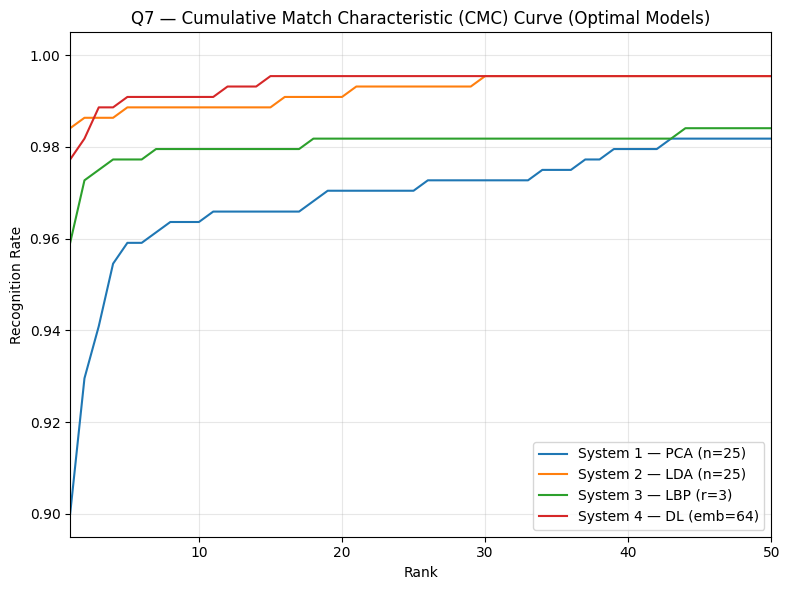

                             System  Rank-1 Rate
--------------------------------------------------
              System 1 — PCA (n=25)       0.9000
              System 2 — LDA (n=25)       0.9841
               System 3 — LBP (r=3)       0.9591
             System 4 — DL (emb=64)       0.9773


In [65]:
systems_cmc_opt = [
    (dist_pca_opt, "System 1 — PCA (n=25)"),
    (dist_lda_opt, "System 2 — LDA (n=25)"),
    (dist_lbp_opt, "System 3 — LBP (r=3)"),
    (dist_dl_opt,  "System 4 — DL (emb=64)"),
]

fig, ax = plt.subplots(figsize=(8, 6))

for dist_matrix, name in systems_cmc_opt:
    cmc = compute_cmc(np.array(dist_matrix), labels)
    ax.plot(range(1, len(cmc) + 1), cmc, label=name)

ax.set_title("Q7 — Cumulative Match Characteristic (CMC) Curve (Optimal Models)")
ax.set_xlabel("Rank")
ax.set_ylabel("Recognition Rate")
ax.set_xlim(1, 50)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'System':>35} {'Rank-1 Rate':>12}")
print("-" * 50)

for dist_matrix, name in systems_cmc_opt:
    cmc = compute_cmc(np.array(dist_matrix), labels)
    print(f"{name:>35} {cmc[0]:>12.4f}")

## V. Selectable task set

<b>The student should choose a number of tasks equivalent to <u>at least 8pts</u> from the list below (pts are not related to the grades)</b>.

1. Evaluate your system on the other two datasets (AT&T, LFW). Feel free to subsample datasets if they are too memory-consuming on your system. (2pt.)
2. Implement 2 different face detectors and compare all techniques to the ground truth bounding boxes provided in <em>CalTechFacesDirs/ImageData.mat</em>. Look up the literature for methods to compare different face detectors. (2pt.)
4. Implement a classification-based scoring method, using an advanced classifier of your choice. Evaluate this system in an identification and verification scenario. (Hint: Follow steps introduced in section 'Distance-based and classification-based scoring') (4pt.)
5. Experiment with the Siamese deep learning model by implementing a different loss function or a different distance calculation layer. (2pt.)
6. Pre-train your deep learning network on a different (larger) dataset and then fine-tune it with CALTECH and compare the results. (4pt.)
7. Implement a different deep learning model* (6pt.)
8. Implement and evaluate a deep learning model for face detection. You can come up with your own architecture or look into the literature what already exists (e.g. YOLO models) (6pt).
9. [ . ] Create a biometric identification or authentication system on a modality of choice and evaluate it (6pt)
    - e.g. keystroke paterns
    - Excludes; Fingerprints, irises and faces
    - **Example datasets are available on Toledo under "Datasets"**
    - You can also choose another dataset you find yourself. If you are unsure whether a modality/dataset is suited for this task,       please send an email to the TA team.
    - If you also picked this option for assignment two, this has to be a **different architecture AND a different modality**.

**For options involving deep learning models: Check out the extra guidelines for neural network-based implementations under "Assignments/Guidelines/" on Toledo**

<em>Note: Indicate clearly which tasks you end up choosing and where we can find the implementations and/or results. </em>

[*] The implemented network has to be significantly different, adding some layers like batch normalisation, dropout, ... to the current network or increasing the kernel size, amount of filters and activation functions does not count.

For the submission deadlines consult the slides in the “practical info module” on Toledo.

For the guidelines and submission instructions consult "Assignments/Guidelines/" on Toledo


In [13]:
from scipy.spatial.distance import euclidean
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score, roc_auc_score
from localmodules.local_binary_patterns import LBP
import localmodules.siamese as siamese
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

def compute_distance_matrix(embeddings, metric):
    n = len(embeddings)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = metric(embeddings[i], embeddings[j])
            D[i, j] = d
            D[j, i] = d
    return D

def CHI2(u, v):
    return np.sum((u - v)**2 / (u + v + 1e-10))

def extract_scores(dist_matrix, labels):
    n = len(labels)
    scores, genuine_id = [], []
    for i in range(n):
        for j in range(i+1, n):
            scores.append(dist_matrix[i, j])
            genuine_id.append(1 if labels[i] == labels[j] else 0)
    return np.array(genuine_id), np.array(scores)

def compute_cmc(similarity_matrix, labels):
    n = similarity_matrix.shape[0]
    ranks = np.zeros(n, dtype=int)
    for i in range(n):
        row = similarity_matrix[i].copy()
        row[i] = -np.inf
        sorted_indices = np.argsort(row)[::-1]
        for rank, idx in enumerate(sorted_indices):
            if labels[idx] == labels[i]:
                ranks[i] = rank + 1
                break
    cmc = np.array([np.sum(ranks <= k) / n for k in range(1, n + 1)])
    return cmc

def holdout_split(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

In [14]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from localmodules.local_binary_patterns import LBP
import localmodules.siamese as siamese
from tensorflow.keras.optimizers import Adam
from scipy.spatial.distance import euclidean

# ── PCA (optimal: n_components=25) ───────────────────────────────────────────
pca_opt = PCA(n_components=25, svd_solver='randomized', whiten=True).fit(faces.data)
emb_pca_opt = pca_opt.transform(faces.data)
dist_pca_opt = compute_distance_matrix(emb_pca_opt, euclidean)
print("PCA done")

# ── LDA (optimal: n_components=25) ───────────────────────────────────────────
lda_opt = LinearDiscriminantAnalysis(n_components=25).fit(faces.data, faces.target)
emb_lda_opt = lda_opt.transform(faces.data)
dist_lda_opt = compute_distance_matrix(emb_lda_opt, euclidean)
print("LDA done")

# ── LBP (optimal: radius=3) ───────────────────────────────────────────────────
lbp_opt = LBP(numPoints=8, radius=3, grid_x=7, grid_y=7)
emb_lbp_opt = lbp_opt.describe_list(faces.images[..., 0])
dist_lbp_opt = compute_distance_matrix(emb_lbp_opt, CHI2)
print("LBP done")

# ── DL (optimal: embedding_size=64) ──────────────────────────────────────────
encoder_opt, model_opt = siamese.create_siamese_model(imshape, 64)
x_train, x_test, y_train, y_test = holdout_split(
    *siamese.get_siamese_paired_data(faces.images, faces.target))
model_opt.compile(loss=siamese.contrastive_loss, optimizer=Adam(),
                  metrics=[siamese.accuracy], run_eagerly=True)
model_opt.fit([x_train[:, 0], x_train[:, 1]], y_train,
              validation_split=0.2, batch_size=32, verbose=2, epochs=10)
emb_dl_opt = encoder_opt(faces.images.astype(np.float32)).numpy()
dist_dl_opt = compute_distance_matrix(emb_dl_opt, euclidean)
print("DL done")

print("All models trained on Caltech!")

PCA done
LDA done
LBP done
Epoch 1/10
40/40 - 8s - loss: 0.0966 - accuracy: 0.7289 - val_loss: 0.0539 - val_accuracy: 0.8719 - 8s/epoch - 210ms/step
Epoch 2/10
40/40 - 7s - loss: 0.0341 - accuracy: 0.9500 - val_loss: 0.0357 - val_accuracy: 0.9250 - 7s/epoch - 171ms/step
Epoch 3/10
40/40 - 7s - loss: 0.0223 - accuracy: 0.9781 - val_loss: 0.0245 - val_accuracy: 0.9531 - 7s/epoch - 167ms/step
Epoch 4/10
40/40 - 7s - loss: 0.0167 - accuracy: 0.9844 - val_loss: 0.0221 - val_accuracy: 0.9688 - 7s/epoch - 166ms/step
Epoch 5/10
40/40 - 7s - loss: 0.0116 - accuracy: 0.9945 - val_loss: 0.0184 - val_accuracy: 0.9812 - 7s/epoch - 169ms/step
Epoch 6/10
40/40 - 7s - loss: 0.0088 - accuracy: 0.9961 - val_loss: 0.0165 - val_accuracy: 0.9812 - 7s/epoch - 168ms/step
Epoch 7/10
40/40 - 7s - loss: 0.0062 - accuracy: 0.9977 - val_loss: 0.0134 - val_accuracy: 0.9812 - 7s/epoch - 163ms/step
Epoch 8/10
40/40 - 7s - loss: 0.0049 - accuracy: 0.9984 - val_loss: 0.0124 - val_accuracy: 0.9844 - 7s/epoch - 167ms/st

2026-05-09 08:30:54.337000: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.
2026-05-09 08:30:54.831943: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.
2026-05-09 08:30:55.680133: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 456192000 exceeds 10% of free system memory.


DL done
All models trained on Caltech!


In [15]:
from sklearn.datasets import fetch_olivetti_faces
from skimage.transform import resize as sk_resize

att = fetch_olivetti_faces(shuffle=True, random_state=42)
att_images_resized = np.array([sk_resize(img, (47, 47), anti_aliasing=True) for img in att.images])
att_targets = att.target
att_data = att_images_resized.reshape(len(att_images_resized), -1).astype(np.float32)

print(f"AT&T: {len(att_images_resized)} images, shape: {att_images_resized.shape}")
print(f"Flat data shape: {att_data.shape}")  # should be (400, 2209)

emb = pca_opt.transform(att_data)
D_pca_att = compute_distance_matrix(emb, euclidean)

emb = lda_opt.transform(att_data)
D_lda_att = compute_distance_matrix(emb, euclidean)

emb = lbp_opt.describe_list(att_images_resized)
D_lbp_att = compute_distance_matrix(emb, CHI2)

imgs_4d = att_images_resized[..., np.newaxis]
emb = encoder_opt(imgs_4d.astype(np.float32)).numpy()
D_dl_att = compute_distance_matrix(emb, euclidean)

att_systems = [('PCA', D_pca_att), ('LDA', D_lda_att), ('LBP', D_lbp_att), ('DL', D_dl_att)]
print("AT&T evaluation done!")

AT&T: 400 images, shape: (400, 47, 47)
Flat data shape: (400, 2209)


/usr/local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
2026-05-09 08:34:29.713945: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 414720000 exceeds 10% of free system memory.
2026-05-09 08:34:29.842199: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 414720000 exceeds 10% of free system memory.


AT&T evaluation done!


In [16]:
import numpy as np
from sklearn.datasets import fetch_lfw_people
from skimage.transform import resize as sk_resize

lfw_raw = fetch_lfw_people(min_faces_per_person=8, resize=0.5, color=False)

# ── Take a random subset to keep it manageable ────────────────────────────
np.random.seed(42)
subset_size = 500
idx = np.random.choice(len(lfw_raw.images), size=subset_size, replace=False)

lfw_images  = np.array([sk_resize(lfw_raw.images[i], (47, 47), anti_aliasing=True) for i in idx])
lfw_targets = lfw_raw.target[idx]
lfw_data    = lfw_images.reshape(len(lfw_images), -1).astype(np.float32)

print(f"LFW subset: {len(lfw_images)} images, {len(np.unique(lfw_targets))} subjects")

emb = pca_opt.transform(lfw_data)
D_pca_lfw = compute_distance_matrix(emb, euclidean)

emb = lda_opt.transform(lfw_data)
D_lda_lfw = compute_distance_matrix(emb, euclidean)

emb = lbp_opt.describe_list(lfw_images)
D_lbp_lfw = compute_distance_matrix(emb, CHI2)

imgs_4d = lfw_images[..., np.newaxis]
emb = encoder_opt(imgs_4d.astype(np.float32)).numpy()
D_dl_lfw = compute_distance_matrix(emb, euclidean)

lfw_systems = [('PCA', D_pca_lfw), ('LDA', D_lda_lfw), ('LBP', D_lbp_lfw), ('DL', D_dl_lfw)]
print("LFW done!")

LFW subset: 500 images, 162 subjects


/usr/local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


LFW done!


In [ ]:
def extract_verification_scores(dist_matrix, targets):
    """Extract genuine_id and scores from a distance matrix and label array."""
    targets = np.array(targets)
    N = len(targets)
    genuine_id = []
    scores = []
    for i in range(N):
        for j in range(i + 1, N):
            scores.append(dist_matrix[i, j])
            genuine_id.append(1 if targets[i] == targets[j] else 0)
    return np.array(genuine_id), np.array(scores)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, average_precision_score

att_targets_arr = np.array(att_targets)

systems_att = [
    (*extract_verification_scores(D_pca_att, att_targets_arr), "PCA — AT&T"),
    (*extract_verification_scores(D_lda_att, att_targets_arr), "LDA — AT&T"),
    (*extract_verification_scores(D_lbp_att, att_targets_arr), "LBP — AT&T"),
    (*extract_verification_scores(D_dl_att,  att_targets_arr), "DL  — AT&T"),
]

# ── AUC-ROC table ──────────────────────────────────────────────────────────
print(f"{'System':>25} {'AUC-ROC':>10}")
print("-" * 38)
for genuine_id, scores, name in systems_att:
    print(f"{name:>25} {roc_auc_score(genuine_id, -scores):>10.4f}")

# ── FAR / FRR + EER ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (genuine_id, scores, name) in enumerate(systems_att):
    fpr, tpr, thresholds = roc_curve(genuine_id, -scores)
    frr = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - frr))
    eer = (fpr[eer_idx] + frr[eer_idx]) / 2
    eer_threshold = -thresholds[eer_idx]
    print(f"{name}: EER = {eer:.4f} at threshold = {eer_threshold:.4f}")
    axes[idx].plot(-thresholds, fpr,  color='red',   label='FAR (FPR)')
    axes[idx].plot(-thresholds, frr,  color='blue',  label='FRR (1-TPR)')
    axes[idx].axvline(eer_threshold, color='green', linestyle='--', label=f'EER ≈ {eer:.4f}')
    axes[idx].scatter([eer_threshold], [eer], color='green', zorder=5)
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Decision Threshold (η)")
    axes[idx].set_ylabel("Error Rate")
    axes[idx].legend(); axes[idx].grid(True, alpha=0.3)

plt.suptitle("Task 1 — FAR/FRR/EER — AT&T Dataset", fontsize=14)
plt.tight_layout(); plt.show()

# ── Precision-Recall ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for genuine_id, scores, name in systems_att:
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    ax.plot(recall, precision, label=name)
baseline = systems_att[0][0].sum() / len(systems_att[0][0])
ax.axhline(y=baseline, color='black', linestyle='--', label=f'Baseline ≈ {baseline:.4f}')
ax.set_title("Task 1 — Precision-Recall — AT&T Dataset")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n{'System':>25} {'AUC-PR':>10} {'Avg Prec':>10}")
print("-" * 48)
for genuine_id, scores, name in systems_att:
    precision, recall, _ = precision_recall_curve(genuine_id, -scores)
    print(f"{name:>25} {auc(recall, precision):>10.4f} {average_precision_score(genuine_id, -scores):>10.4f}")

# ── CMC + Rank-1 ───────────────────────────────────────────────────────────
systems_cmc_att = [
    (D_pca_att, "PCA — AT&T"),
    (D_lda_att, "LDA — AT&T"),
    (D_lbp_att, "LBP — AT&T"),
    (D_dl_att,  "DL  — AT&T"),
]

fig, ax = plt.subplots(figsize=(8, 6))
for dist_matrix, name in systems_cmc_att:
    cmc = compute_cmc(np.array(dist_matrix), att_targets_arr)
    ax.plot(range(1, len(cmc) + 1), cmc, label=name)
ax.set_title("Task 1 — CMC Curve — AT&T Dataset")
ax.set_xlabel("Rank"); ax.set_ylabel("Recognition Rate")
ax.set_xlim(1, 40); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'System':>25} {'Rank-1':>10}")
print("-" * 38)
for dist_matrix, name in systems_cmc_att:
    cmc = compute_cmc(np.array(dist_matrix), att_targets_arr)
    print(f"{name:>25} {cmc[0]:>10.4f}")